In [291]:
import numpy as np
import pandas as pd
import straxen
from register_conor_plugins import register_conor_plugins
from conor_plugins import data_selection
import new_model as mod2

In [179]:
st = straxen.contexts.xenonnt_online()

You specified _auto_append_rucio_local=True and you are not on dali compute nodes, so we will add the following rucio local path: /project/lgrandi/rucio/


In [180]:
st = register_conor_plugins(st)

In [4]:
# runs = st.select_runs(run_id = "026195")
#
# runs

In [292]:
run_id = "026195"

In [182]:
peaks = st.get_df(run_id, ("peak_basics", "peaks", "peak_positions_cnf"))

Option diffusion_constant not taken by any registered plugin
Option diffusion_constant not taken by any registered plugin


AutoReconnect: fried.rice.edu:27017: connection closed (configured timeouts: socketTimeoutMS: 60000.0ms, connectTimeoutMS: 60000.0ms)

In [7]:
# np.save('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/processed_peak_data.npy', peaks)
#np.save('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/run_data.npy', runs)

In [293]:
peaks = np.load('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/processed_peak_data.npy', allow_pickle=True)
runs = np.load('/mnt/c/Users/Aidan/DataspellProjects/xenon_project/strax_data/run_data.npy', allow_pickle=True)

In [294]:
runs_df = pd.DataFrame(runs, columns = ["name", "number", "mode", "end", "start", "source", "tags", "livetime","event_basics_available", "peak_basics_available"])
runs_df

,name,number,mode,end,start,source,tags,livetime,event_basics_available,peak_basics_available
0,026195,26195,background_linked,2021-08-04 10:02:04.212,2021-08-04 10:00:31.446,none,"_sr0,_failed_cevns_ac_model",0 days 00:01:32.766000,True,True


In [354]:
import importlib
importlib.reload(data_selection)

You specified _auto_append_rucio_local=True and you are not on dali compute nodes, so we will add the following rucio local path: /project/lgrandi/rucio/
('subtype_mask',) 0.2.1
('pS2_relabel',) 0.0.0
('wf_piecewise_info',) 0.0.1
('n_electron_rec',) 0.0.2


<module 'conor_plugins.data_selection' from '/mnt/c/Users/Aidan/DataspellProjects/xenon_project/conor_plugins/data_selection.py'>

In [355]:
pS2s, DEs, S1s, peaks, _ , debug= data_selection.data_selection_new(runs_df)


Option diffusion_constant not taken by any registered plugin



-------------------------------------------------------------------------------------------------------------------

Now looking at run: 0    026195
Name: name, dtype: object


Option diffusion_constant not taken by any registered plugin
Option diffusion_constant not taken by any registered plugin
Loading plugins: |██████████| 100.00 % [00:09<00:00], #4 (0.19 s). 33.4 MB/s
Option diffusion_constant not taken by any registered plugin


DAQ veto intervals not found, oop

70 values reassigned from pS2s into all_DEs (or cut entirely)
21951 single- or few-electron signals cut, 
representing 89.19% of all single- or few-electron signals

Length of run: 92.77s
Loaded 188.5 MB of peaks-data (13.5 MB of which are pS2s and DEs)
204 electrons cut, representing 7.70% of all electrons

--------------------------------------------------------------------------------
Selection diagnostics
--------------------------------------------------------------------------------

Final DEs: 2444 peaks
  subtype 21: 2441
  subtype 272: 3

Final pS2s: 805 peaks
  subtype 22: 408
  subtype 25: 127
  subtype 29: 41
  subtype 261: 31
  subtype 262: 198


/home/aidan/miniforge3/envs/xenon/lib/python3.11/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')



All small candidates: area <= 500 and n_electron_rec <= 5: 45969 peaks
  subtype 0: 19638
  subtype 11: 224
  subtype 12: 152
  subtype 13: 2426
  subtype 20: 121
  subtype 21: 8734
  subtype 28: 48
  subtype 271: 985
  subtype 272: 5390
  subtype 273: 8251

Small candidates classified as pS2s: 0 peaks

Small candidates selected as neither DE nor pS2: 43525 peaks
  subtype 0: 19638
  subtype 11: 224
  subtype 12: 152
  subtype 13: 2426
  subtype 20: 121
  subtype 21: 6293
  subtype 28: 48
  subtype 271: 985
  subtype 272: 5387
  subtype 273: 8251

Suspicious final DEs: PH/fake or area>150 or n_electron_rec>2: 37 peaks
  subtype 21: 34
  subtype 272: 3

Suspicious DE summary:
  area min/median/max: 21.317728 91.78536 175.36748
  n_electron_rec unique: (array([1, 3, 4, 5], dtype=int32), array([ 3, 15, 10,  9]))
  range_50p_area ms min/median/max: 0.00020443872 0.0136412885 0.04285967
--------------------------------------------------------------------------------



In [318]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.colors import LogNorm
from multihist import Hist1d, Histdd

avg_livetime_sec = np.mean([(runs_df['end'].iloc[i].value - runs_df['start'].iloc[i].value) for i in range(len(runs_df))])/1e9
print(f"Average livetime per run: {avg_livetime_sec:.1f} s")

def plot_area_width_histogram(
    peaks,
    livetime_sec,
    pe_bins=np.logspace(0, 7, 120),
    width_bins=np.geomspace(2, 1e5, 120),
    extra_labels=tuple(),
    rate_range=(1e-4, 1),
    figsize=(7, 5),
):
    """
    Plot (area, width) histogram of peak rate.

    Parameters
    ----------
    peaks : array-like
        Peaks with fields 'area' and 'range_50p_area'.
    livetime_sec : float
        Livetime in seconds (for normalizing rates).
    pe_bins : array-like
        Bin edges for peak area [PE].
    width_bins : array-like
        Bin edges for range_50p_area [ns].
    extra_labels : list of tuples
        Extra text labels as (area, width, text, color).
    rate_range : tuple
        Color scale range for rates [peaks/(bin*s)].
    figsize : tuple
        Figure size.
    """

    mh = Histdd(
        peaks,
        dimensions=(
            ("area", pe_bins),
            ("range_50p_area", width_bins),
        ),
    )

    fig, ax = plt.subplots(figsize=figsize)

    (mh / livetime_sec).plot(
        norm=LogNorm(vmin=rate_range[0], vmax=rate_range[1]),
        colorbar=False,                 # <— turn off auto colorbar
    )

    # build your own colorbar from the plotted mappable
    mappable = ax.collections[-1] if ax.collections else ax.images[-1]
    cbar = fig.colorbar(mappable, ax=ax)
    cbar.ax.tick_params(labelsize=12)          # tick label size
    cbar.set_label("Peaks / (bin * s)", fontsize=14)

    # styling
    ax.set_facecolor("k")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Area [PE]", fontsize =14)
    ax.set_ylabel("Range 50% area [ns]", fontsize=14)

    # # Add standard physics labels
    # labels = [
    #     (3, 150, "1PE\npileup", "w"),
    #     (30, 200, "1e", "w"),
    #     (100, 1000, "n-e", "w"),
    #     (3000, 2.5e4, "e-bursts", "w"),
    #     (1200, 50, "S1", "w"),
    #     (2e5, 800, "S2", "w"),
    # ] + list(extra_labels)

    # for x, w, text, color in labels:
    #     t = ax.text(
    #         x, w, text, color=color,
    #         va="center", ha="center", fontsize=14,
    #     )
    #     # Add outline (stroke)
    #     t.set_path_effects([
    #         path_effects.Stroke(linewidth=2, foreground='black'),
    #         path_effects.Normal()
    #     ])

    fig.tight_layout()
    return fig, ax

Average livetime per run: 92.8 s


Text(0.5, 1.0, 'S1s')

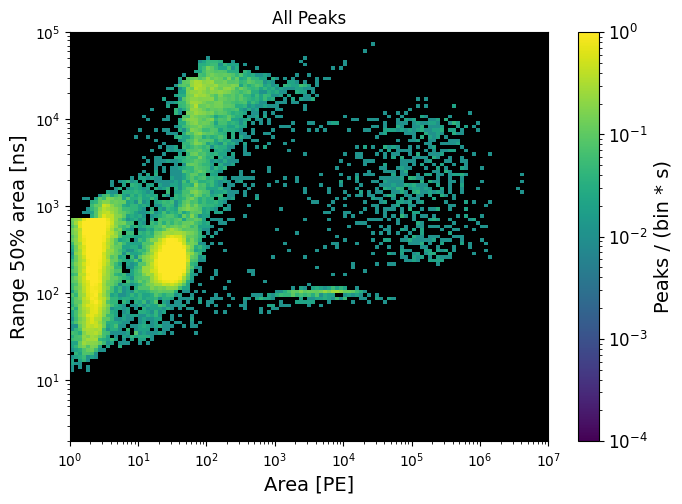

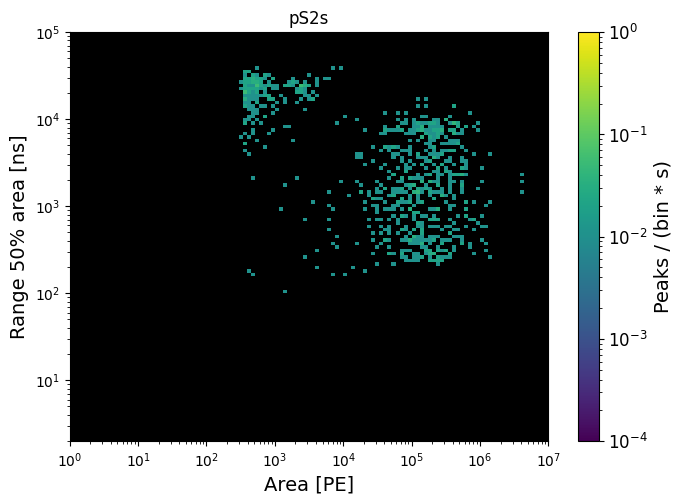

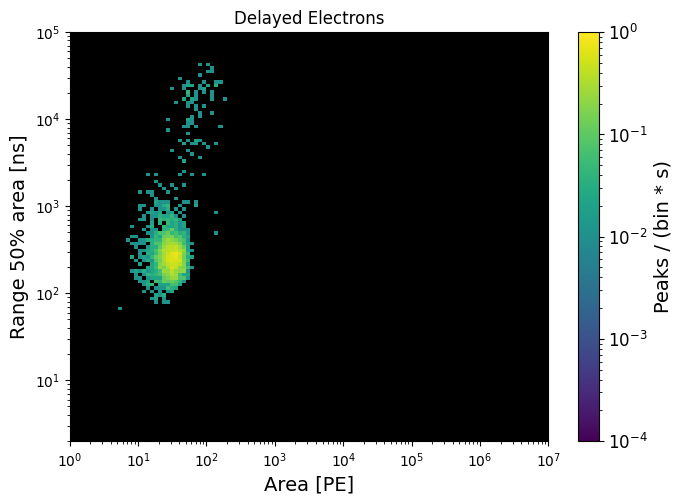

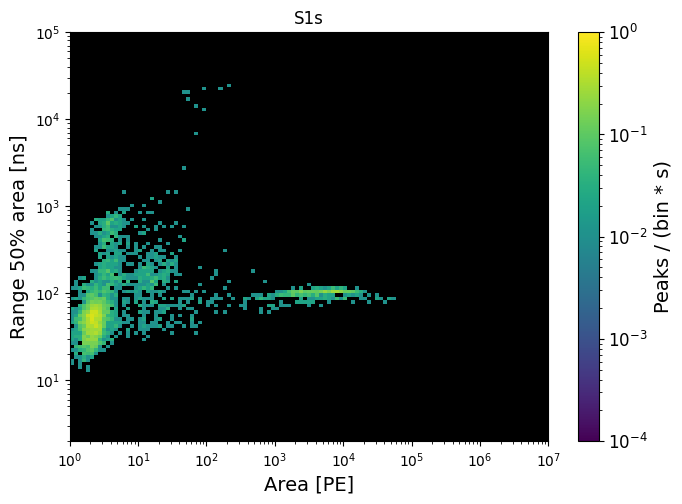

In [319]:
fig, ax = plot_area_width_histogram(peaks=peaks, livetime_sec=livetime)
ax.set_title("All Peaks")

fig, ax = plot_area_width_histogram(peaks=pS2s, livetime_sec=livetime)
ax.set_title("pS2s")

fig, ax = plot_area_width_histogram(peaks=DEs, livetime_sec=livetime)
ax.set_title("Delayed Electrons")

fig, ax = plot_area_width_histogram(peaks=S1s, livetime_sec=livetime)
ax.set_title("S1s")


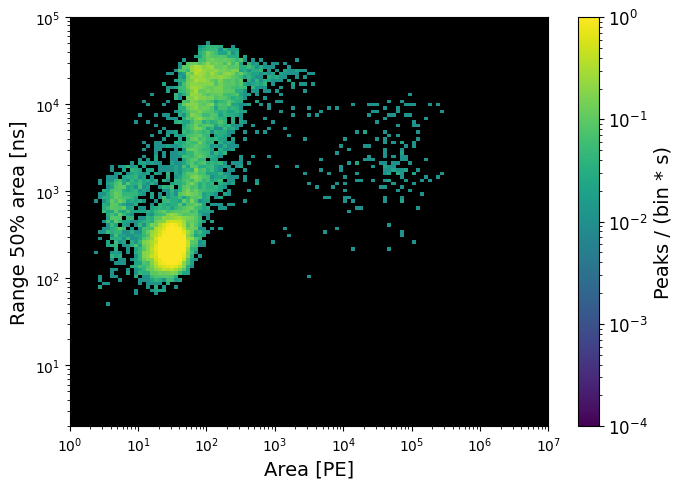

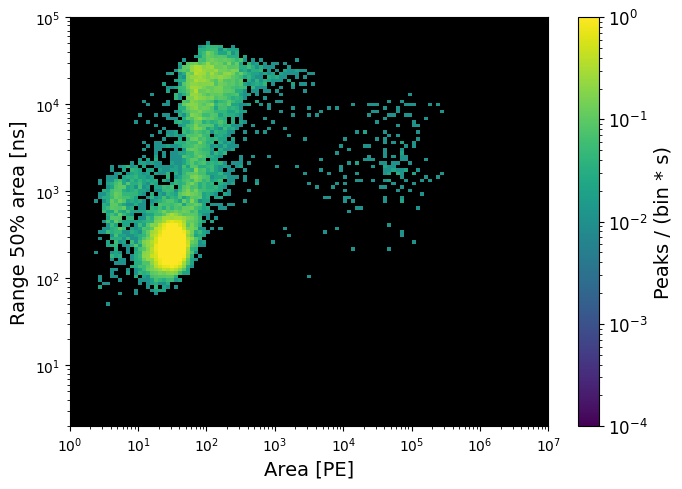

In [14]:
#looking at this I lowkey think that it contains misclassified pS2s, since some signals are quite big
#my run is only 90 seconds, so you don't see many, but there would probably be many in longer runs
all_des = peaks[np.isin(peaks['subtype'], [20, 21, 23, 271, 272, 273])]
DEs_final = DEs

#Want to plot all DEs that aren't in the final DEs selection
# Create a mask for signals NOT in the final DEs
mask = ~np.isin(all_des['time'], DEs_final['time'])

# Plot the excluded ones
fig, ax = plot_area_width_histogram(
    peaks=all_des[mask],
    livetime_sec=livetime
)

fig1, ax1 = plot_area_width_histogram(
    peaks=all_des,
    livetime_sec=livetime
)


In [274]:
import importlib
import random
from conor_plugins import model as mod
importlib.reload(mod)

<module 'conor_plugins.model' from '/mnt/c/Users/Aidan/DataspellProjects/xenon_project/conor_plugins/model.py'>

In [ ]:
#Create random selections of some windows, and plot them using mod.time_fitting
#Getting some example histogram model plots
#random.seed(48)
source_like = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
]

burst_source = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] > 5)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [20, 271, 272, 273])
]

burst_source_no_overlap = burst_source[
    ~np.isin(burst_source["time"], source_like["time"])
]
run_duration = (runs_df.iloc[0]['end'].value - runs_df.iloc[0]['start'].value)/1e9

window_size = (92.766/92.766) #seconds
base_width = 0.5 #seconds
margin = 0.01 #seconds

usable_start = margin
usable_end = run_duration - margin
usable_duration = usable_end - usable_start

n_windows = int(np.ceil(usable_duration / window_size))

p_add_list = []
p_new_list = []
total_rate_add_list = []
total_rate_new_list = []
t_abs_list = []
delta_log_list = []
run_duration_list = []


for i in range(n_windows):

    start_sec = usable_start + i * window_size
    end_sec = min(start_sec + window_size, usable_end)

    if end_sec <= start_sec:
        break

    print(f"\n  window: {start_sec} - {end_sec} seconds")
    # vals, cov, _, _, _ = mod.time_fitting(runs_df.iloc[0], pS2s_93_ku, DEs_93_ku, seconds_range = (start_sec, end_sec), plot = False, model = 'old')
    #_, vals_new, cov_new, _, _, BIC_new = mod.time_fitting(runs_df.iloc[0], pS2s, DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'new')
    # vals_radial, cov_radial, _, _, _ = mod.time_fitting(runs_df.iloc[0], pS2s_93, DEs_93[DEs_93['r'] < 45], S1s_93['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'radial')
    #_, vals_exp, cov_exp, _, _, BIC_ep = mod.time_fitting(runs_df.iloc[0], pS2s, DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'exp')
    _, vals_exp_add, cov_exp_add, _, _, BIC_add = mod.time_fitting(runs_df.iloc[0], pS2s, source_like, burst_source_no_overlap, DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), plot = False, model = 'exp_additive')
    #_, vals_pure_exp, cov_pure_exp, _,_, BIC_pure = mod.time_fitting(runs_df.iloc[0], pS2s, DEs, S1s['time_since_start'],
                                                              #seconds_range = (start_sec, end_sec), plot = False, model = 'pure_exp')
    _, vals_extra, cov_extra,_,_,BIC_extra = mod.time_fitting(runs_df.iloc[0], pS2s, source_like, burst_source_no_overlap, DEs, S1s["time_since_start"], seconds_range = (start_sec, end_sec), plot = False, model = 'extra_source')


    # pS2s_region = pS2s_93_ku[(pS2s_93_ku['time_since_start'] >= start_sec*1e3) & (pS2s_93_ku['time_since_start'] <= end_sec*1e3)]
    # DEs_region = DEs_93_ku[(DEs_93_ku['time_since_start'] >= start_sec*1e3) & (DEs_93_ku['time_since_start'] <= end_sec*1e3)]
    pS2s_region_new = pS2s[(pS2s['time_since_start'] >= start_sec*1e3) & (pS2s['time_since_start'] <= end_sec*1e3)]
    DEs_region_new = DEs[(DEs['time_since_start'] >= start_sec*1e3) & (DEs['time_since_start'] <= end_sec*1e3)]
    S1_region = S1s[(S1s['time_since_start'] >= start_sec*1e3) & (S1s['time_since_start'] <= end_sec*1e3)]
    # DEs_cut_region_new = DEs_region_new[DEs_region_new['r'] < 45]

    available_width = end_sec - start_sec
    n_zooms = int(np.ceil(available_width / base_width))

    # for j in range(n_zooms):
    #     start_zoom = j*base_width
    #     if start_zoom >= available_width:
    #         break
    #
    #     zoom_width = min(base_width, available_width - start_zoom)
    #     if zoom_width < 0:
    #         break
    #
    #     plot_zoom = (start_zoom, zoom_width)
    #     print(f"  Zoom region: {start_zoom:.1f} - {start_zoom + zoom_width:.1f} seconds within window")
    #     print("running cdf_plot")
    #
    #     zoom_start_abs_ms = start_sec * 1e3 + start_zoom * 1e3
    #     zoom_stop_abs_ms = zoom_start_abs_ms + zoom_width * 1e3
    #
    #     se_zoom_times = DEs_region_new[
    #     (DEs_region_new["time_since_start"] >= zoom_start_abs_ms)
    #     & (DEs_region_new["time_since_start"] <= zoom_stop_abs_ms)
    #     ]["time_since_start"]
    #     resolution_ms = 10
    #     bins = np.arange(zoom_start_abs_ms, zoom_stop_abs_ms + resolution_ms, resolution_ms)
    #     hist, _ = np.histogram(se_zoom_times, bins=bins)
    #
    #     if hist.max() < 1:
    #         print(f"Skipping zoom {start_zoom:.1f}-{start_zoom + zoom_width:.1f}: max bin count only {hist.max()}")
    #         continue
    #     total_rate_new, p_new, t_abs, rate_new = mod.cdf_plot(
    #     pS2s_region_new,
    #     DEs_region_new,
    #     S1_region['time_since_start'],
    #     vals_new,
    #     cov_new,
    #     model='new',
    #     label='Pure power law',
    #     color='blue',
    #     seconds_range=(start_sec, end_sec),
    #     plot_zoom=plot_zoom,
    #     extra_models=[
    #     {
    #         "model": "exp_additive",
    #         "values": vals_exp_add,
    #         "cov": cov_exp_add,
    #         "label": "Exp + power law",
    #         "color": "orange",
    #         "linestyle": "-"
    #     },
    #     {
    #     "model": "exp",
    #     "values": vals_exp,
    #     "cov": cov_exp,
    #     "label": "Exp-to-power-law",
    #     "color": "blue",
    #     "linestyle": "--"
    #     }],
    #     show_model_errors= False
    #     )



        # print("Running new")
        # total_rate_new, p_new, t_abs, rate_new = mod.cdf_plot(pS2s_region_new, DEs_region_new, S1_region['time_since_start'], vals_new, cov_new, model = 'new', seconds_range = (start_sec, end_sec), plot_zoom = plot_zoom)
        # #  print("Running exp")
        # #  mod.cdf_plot(pS2s_region_new, DEs_region_new, S1_region['time_since_start'], vals_exp, cov_exp, model = 'exp', seconds_range = (start_sec, end_sec), plot_zoom = (start_zoom, width))
        # print("running exp additive")
        # total_rate_exp_add, p_exp_add, _, rate_add = mod.cdf_plot(pS2s_region_new, DEs_region_new, S1_region['time_since_start'], vals_exp_add, cov_exp_add, model = 'exp_additive', seconds_range = (start_sec, end_sec), plot_zoom = plot_zoom)
        #
        # mask = ((rate_new > 0) & (rate_add > 0) & np.isfinite(rate_new) & np.isfinite(rate_add))
        #
        # delta_log = (np.log(rate_add[mask]) - np.log(rate_new[mask]))
        # delta_log_list.append(delta_log)
        # t_abs_list.append(t_abs)
        # total_rate_new_list.append(total_rate_new)
        # total_rate_add_list.append(total_rate_exp_add)
        # p_new_list.append(p_new)
        # p_add_list.append(p_exp_add)


  window: 0.01 - 1.01 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: exp_additive
Running without DAQ vetos; cannot guarantee a clean fit.

This selection will incorporate 7 pS2s
Corresponding to the seconds range of: 0 to 1

Running the additive exponential + power-law cost function now



KeyboardInterrupt


KeyboardInterrupt



In [246]:
for i, delta_log in enumerate(delta_log_list):
    delta_log = np.asarray(delta_log)

    # remove nan/inf values, usually from log(0) or log invalid
    #delta_log = delta_log[np.isfinite(delta_log)]

    print(f"\nWindow/zoom {i}")
    print("N valid:", len(delta_log))
    print("sum delta log:", np.sum(delta_log))
    print("mean delta log:", np.mean(delta_log))
    print("median delta log:", np.median(delta_log))
    print("min/max delta log:", np.min(delta_log), np.max(delta_log))

In [128]:
run_duration = (runs_df.iloc[0]['end'].value - runs_df.iloc[0]['start'].value)/1e9
print(run_duration)

92.766


In [160]:
def powerlaw_kernel(u, n, tmin):
    """
    Normalized pure power-law kernel h_pl(u).
    u and tmin should be in the same units, e.g. ms.
    """
    u = np.asarray(u, dtype=float)

    h = np.zeros_like(u)

    mask = u > tmin
    h[mask] = ((n - 1.0) / tmin) * (u[mask] / tmin) ** (-n)

    return h


def exp_kernel(u, tau, tmin):
    """
    Normalized exponential kernel h_exp(u).
    """
    u = np.asarray(u, dtype=float)

    h = np.zeros_like(u)

    mask = u > tmin
    h[mask] = (1.0 / tau) * np.exp(-(u[mask] - tmin) / tau)

    return h


def exp_additive_kernel(u, n, tau, f_exp, tmin):
    """
    Normalized additive kernel:
        h_add = f_exp h_exp + (1 - f_exp) h_pl
    """
    h_exp = exp_kernel(u, tau, tmin)
    h_pl = powerlaw_kernel(u, n, tmin)

    return f_exp * h_exp + (1.0 - f_exp) * h_pl

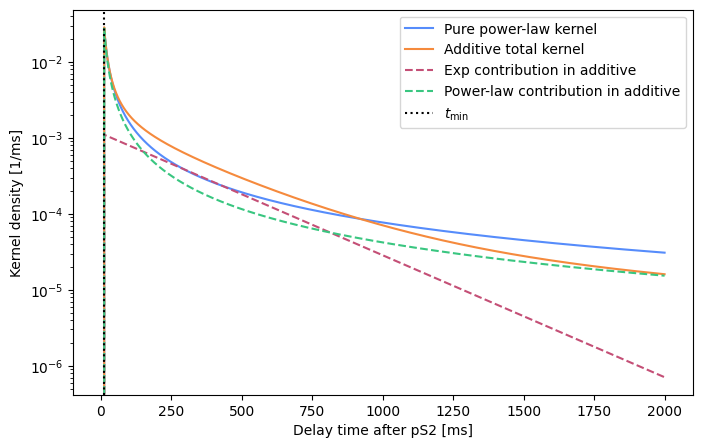

In [254]:
#power law fit
n_pl = 1.318818
tmin_pl = 11.5

# Additive fit
n_add = 1.454677
tau_add = 270.6065
f_exp = 0.2969685
tmin_add = 11.5

#Exponential fit
tau_exp = 70.235917
tmin_exp = 11.5

u = np.linspace(0, 2000, 5000)  # delay time in ms

h_pl = powerlaw_kernel(u, n_pl, tmin_pl)
h_add = exp_additive_kernel(u, n_add, tau_add, f_exp, tmin_add)
h_exp_component = f_exp * exp_kernel(u, tau_add, tmin_add)
h_pl_component = (1.0 - f_exp) * powerlaw_kernel(u, n_add, tmin_add)
h_pure_exp = exp_kernel(u, tau_exp, tmin_exp)

plt.figure(figsize=(8, 5))
plt.plot(u, h_pl, label="Pure power-law kernel")
plt.plot(u, h_add, label="Additive total kernel")
#plt.plot(u, h_pure_exp, label="Exponential kernel")
plt.plot(u, h_exp_component, "--", label="Exp contribution in additive")
plt.plot(u, h_pl_component, "--", label="Power-law contribution in additive")
plt.axvline(tmin_add, color="k", linestyle=":", label=r"$t_{\min}$")
plt.xlabel("Delay time after pS2 [ms]")
plt.ylabel("Kernel density [1/ms]")
plt.legend()
plt.yscale("log")
plt.show()

In [499]:

print(f"BIC_add = {BIC_add}")
print(f"BIC_extra = {BIC_extra}")

BIC_add = 18514.136031674734
BIC_extra = 18449.676681500983


In [162]:
def powerlaw_cdf(u, n, tmin):
    u = np.asarray(u, dtype=float)
    F = np.zeros_like(u)

    mask = u > tmin
    F[mask] = 1.0 - (tmin / u[mask]) ** (n - 1.0)

    return F


def exp_cdf(u, tau, tmin):
    u = np.asarray(u, dtype=float)
    F = np.zeros_like(u)

    mask = u > tmin
    F[mask] = 1.0 - np.exp(-(u[mask] - tmin) / tau)

    return F


def exp_additive_cdf(u, n, tau, f_exp, tmin):
    return (
        f_exp * exp_cdf(u, tau, tmin)
        + (1.0 - f_exp) * powerlaw_cdf(u, n, tmin)
    )

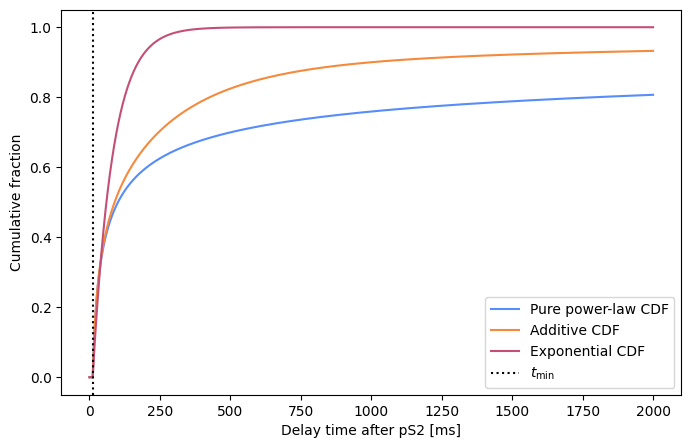

In [215]:
F_pl = powerlaw_cdf(u, n_pl, tmin_pl)
F_add = exp_additive_cdf(u, n_add, tau_add, f_exp, tmin_add)
F_exp = exp_cdf(u, tau_exp, tmin_exp)

plt.figure(figsize=(8, 5))
plt.plot(u, F_pl, label="Pure power-law CDF")
plt.plot(u, F_add, label="Additive CDF")
plt.plot(u, F_exp, label = "Exponential CDF")
plt.axvline(tmin_add, color="k", linestyle=":", label=r"$t_{\min}$")
plt.xlabel("Delay time after pS2 [ms]")
plt.ylabel("Cumulative fraction")
plt.legend()
plt.show()

In [225]:
def compare_model_rates(
    s2_roi,
    s1_roi,
    vals_new,
    vals_add,
    vals_pure_exp,
    window_start_ms,
    window_stop_ms,
    dt_plot_ms=0.5,
    mask_dead=True,
):
    """
    Compare full model rates lambda(t) for pure power-law and additive exp+power-law.

    Parameters
    ----------
    s2_roi:
        Structured pS2 array for this fit window.
    s1_roi:
        Array of S1 times in ms.
    vals_new:
        Fitted parameters for pure power-law:
            s, n, tmin, c, d, k
    vals_add:
        Fitted parameters for additive model:
            s, n, tau, f_exp, tmin, c, d, k
    window_start_ms, window_stop_ms:
        Absolute time-since-run-start bounds in ms.
    dt_plot_ms:
        Model evaluation spacing in ms.
    mask_dead:
        If True, hide dead zones by setting rates to nan for plotting.

    Returns
    -------
    t_abs, rate_new, rate_add, ratio, diff
    """

    t_abs = np.arange(window_start_ms, window_stop_ms + dt_plot_ms, dt_plot_ms)

    total_new, rate_new = mod.multi_powerlaw_wrap(
        t_abs,
        vals_new,
        s2_roi,
        s1_roi,
        window_start_ms,
        window_stop_ms
    )

    total_add, rate_add = mod.multi_exp_additive_wrap(
        t_abs,
        vals_add,
        s2_roi,
        s1_roi,
        window_start_ms,
        window_stop_ms
    )

    total_exp, rate_exp = mod.multi_pure_exp_wrap(
        t_abs,
        vals_pure_exp,
        s2_roi, s1_roi,
        window_start_ms,
        window_stop_ms
    )

    rate_new = np.asarray(rate_new, dtype=float)
    rate_add = np.asarray(rate_add, dtype=float)
    rate_exp = np.asarray(rate_exp, dtype=float)

    if mask_dead:
        # tmin index differs by model. For plotting dead zones, use fitted tmin from either model.
        # Pure power-law: vals_new = [s, n, tmin, c, d, k]
        # Additive: vals_add = [s, n, tau, f_exp, tmin, c, d, k]
        try:
            tmin_plot = vals_add["tmin"]
        except Exception:
            tmin_plot = vals_add[4]

        dead_mask = np.zeros_like(t_abs, dtype=bool)

        for s1_time in s1_roi:
            dead_mask |= (t_abs >= s1_time) & (t_abs <= s1_time + 4.6)

        for s2_time in s2_roi["time_since_start"]:
            dead_mask |= (t_abs >= s2_time) & (t_abs <= s2_time + tmin_plot)

        rate_new[dead_mask] = np.nan
        rate_add[dead_mask] = np.nan
        rate_exp[dead_mask] = np.nan

    def safe_ratio(num, den):
        valid = (
            np.isfinite(num)
            & np.isfinite(den)
            & (num > 0)
            & (den > 0)
        )

        out = np.full_like(num, np.nan, dtype=float)
        out[valid] = num[valid] / den[valid]
        return out

    def safe_diff(a, b):
        valid = np.isfinite(a) & np.isfinite(b)

        out = np.full_like(a, np.nan, dtype=float)
        out[valid] = a[valid] - b[valid]
        return out

    rates = {
        "plaw": rate_new,
        "add": rate_add,
        "exp": rate_exp,
    }

    ratios = {
        "add_over_plaw": safe_ratio(rate_add, rate_new),
        "exp_over_plaw": safe_ratio(rate_exp, rate_new),
        "add_over_exp": safe_ratio(rate_add, rate_exp),
    }

    diffs = {
        "add_minus_plaw": safe_diff(rate_add, rate_new),
        "exp_minus_plaw": safe_diff(rate_exp, rate_new),
        "add_minus_exp": safe_diff(rate_add, rate_exp),
    }

    return t_abs, rates, ratios, diffs

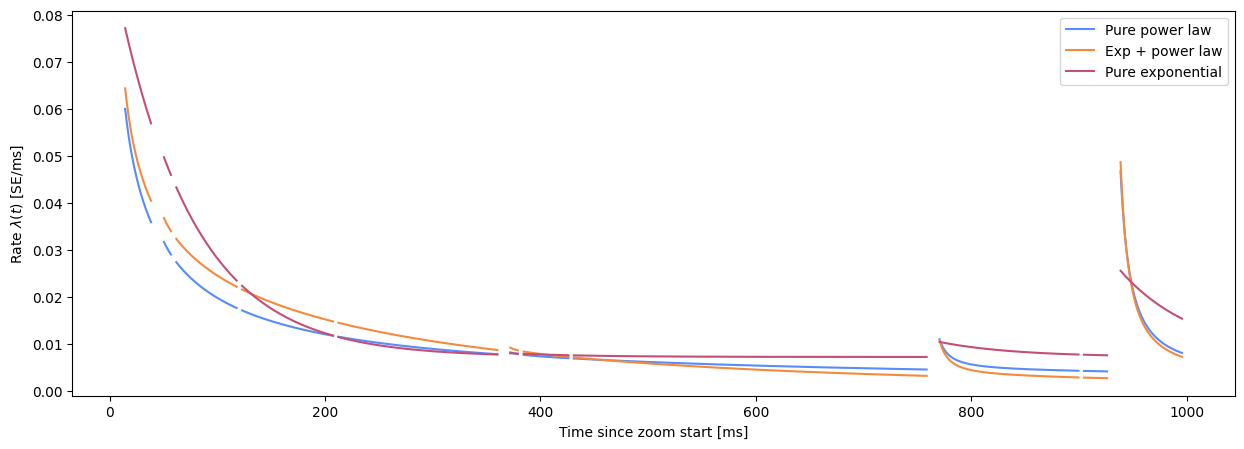

In [227]:
zoom_start_s = 10.0
zoom_width_s = 1.0

zoom_start_ms = window_start_ms + zoom_start_s * 1e3
zoom_stop_ms = zoom_start_ms + zoom_width_s * 1e3

mask_zoom = (t_abs >= zoom_start_ms) & (t_abs <= zoom_stop_ms)

x_zoom = t_abs[mask_zoom] - zoom_start_ms

plt.figure(figsize=(15, 5))
plt.plot(x_zoom, rates['plaw'][mask_zoom], label="Pure power law")
plt.plot(x_zoom, rates['add'][mask_zoom], label="Exp + power law")
plt.plot(x_zoom, rates['exp'][mask_zoom], label="Pure exponential")
plt.xlabel("Time since zoom start [ms]")
plt.ylabel(r"Rate $\lambda(t)$ [SE/ms]")
plt.legend()
plt.show()

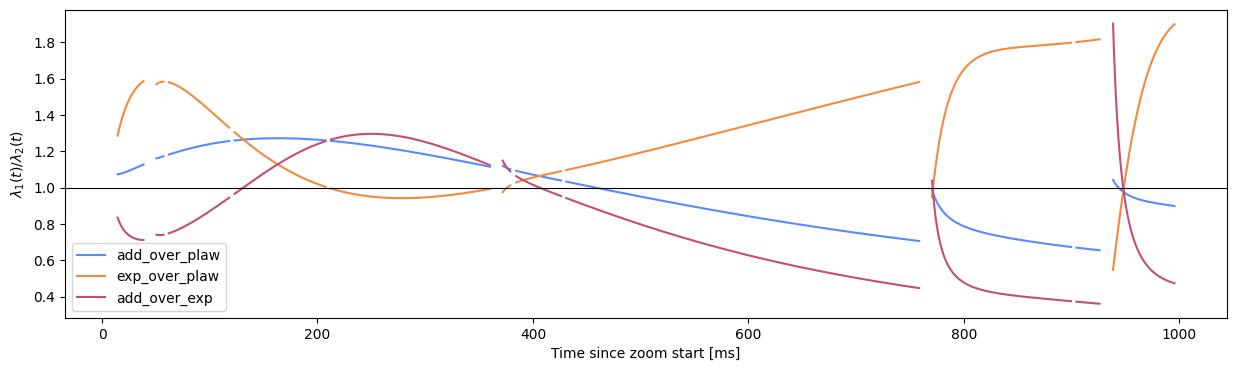

In [230]:
plt.figure(figsize=(15, 4))
plt.plot(x_zoom, ratios['add_over_plaw'][mask_zoom], label = 'add_over_plaw')
plt.plot(x_zoom, ratios['exp_over_plaw'][mask_zoom], label = 'exp_over_plaw')
plt.plot(x_zoom, ratios['add_over_exp'][mask_zoom], label = 'add_over_exp')
plt.axhline(1.0, color="k", linewidth=0.8)
plt.xlabel("Time since zoom start [ms]")
plt.ylabel(r"$\lambda_{\rm 1}(t)/\lambda_{\rm 2}(t)$")
plt.legend()
plt.show()

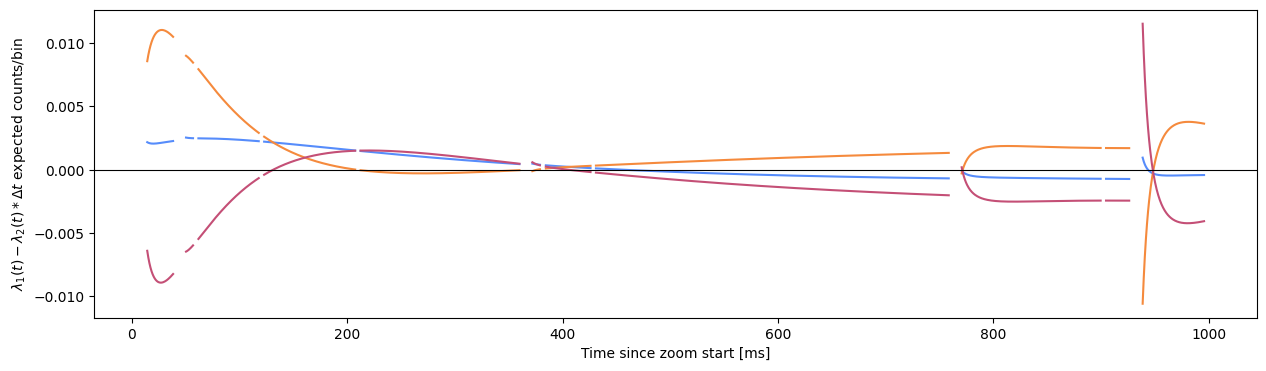

In [232]:
dt_plot_ms = np.nanmedian(np.diff(t_abs))

plt.figure(figsize=(15, 4))
plt.plot(x_zoom, diffs['add_minus_plaw'][mask_zoom] * dt_plot_ms)
plt.plot(x_zoom, diffs['exp_minus_plaw'][mask_zoom] * dt_plot_ms)
plt.plot(x_zoom, diffs['add_minus_exp'][mask_zoom] * dt_plot_ms)
plt.axhline(0.0, color="k", linewidth=0.8)
plt.xlabel("Time since zoom start [ms]")
plt.ylabel(r"$\lambda_{\rm 1}(t) - \lambda_{\rm 2}(t)*\Delta t$ expected counts/bin")
plt.show()

In [260]:
def expected_count_gap(
    model_wrap,
    vals,
    s2_roi,
    s1_roi,
    gap_start_ms,
    gap_stop_ms,
    dt_ms=0.1,
    tmin_ms=None,
    source_like=None,
    burst_source=None,
):
    """
    Integrate the model rate over live intervals inside [gap_start_ms, gap_stop_ms].

    Important:
    - s2_roi/source_like/burst_source should include source history before gap_start_ms.
    - observed DEs are not used here.
    - model normalization window is taken to be the same as the integration gap.
    """

    window_start_ms = gap_start_ms
    window_stop_ms = gap_stop_ms

    if hasattr(s1_roi, "dtype") and s1_roi.dtype.names is not None:
        s1_times_ms = s1_roi["time_since_start"].astype(np.float64)
    else:
        s1_times_ms = np.asarray(s1_roi, dtype=np.float64)

    if tmin_ms is None:
        if hasattr(vals, "__getitem__"):
            try:
                tmin_ms = vals["tmin"]
            except Exception:
                if len(vals) == 6:
                    tmin_ms = vals[2]
                else:
                    tmin_ms = vals[4]

    dead_intervals = mod2.build_dead_intervals(
        gap_start_ms,
        gap_stop_ms,
        s2_roi["time_since_start"],
        s1_times_ms,
        tmin_ms
    )

    live_intervals = mod2.build_live_intervals(
        gap_start_ms,
        gap_stop_ms,
        dead_intervals
    )

    mu = 0.0

    for a, b in live_intervals:
        t = np.arange(a, b, dt_ms)
        if len(t) < 2:
            continue

        if source_like is None:
            _, rate = model_wrap(
                t,
                vals,
                s2_roi,
                s1_times_ms,
                window_start_ms,
                window_stop_ms,
            )
        else:
            _, rate = model_wrap(
                t,
                vals,
                s2_roi,
                source_like,
                burst_source,
                s1_times_ms,
                window_start_ms,
                window_stop_ms,
            )

        mu += np.trapezoid(rate, t)

    return mu, np.exp(-mu), live_intervals

In [121]:
def poisson_deviance(N, mu):
    N = np.asarray(N, dtype=float)
    mu = np.asarray(mu, dtype=float)

    # Broadcast N to same shape as mu
    N = np.broadcast_to(N, mu.shape)

    D = np.zeros_like(mu, dtype=float)

    mask = N > 0
    D[mask] = 2 * (
        mu[mask]
        - N[mask]
        + N[mask] * np.log(N[mask] / mu[mask])
    )

    mask0 = N == 0
    D[mask0] = 2 * mu[mask0]

    return D

In [503]:
D = poisson_deviance(N_arr, mu_arr)

for i in np.argsort(D)[-20:][::-1]:
    print(
        i,
        edges[i],
        edges[i+1],
        "mu =", mu_arr[i],
        "N_obs =", N_arr[i],
        "pull =", (N_arr[i] - mu_arr[i]) / np.sqrt(mu_arr[i]) if mu_arr[i] > 0 else np.nan,
        "D =", D[i],
    )

169 84500 85000 mu = 3.252686997416653 N_obs = 33 pull = 16.494023399463288 D = 93.4290991208977
79 39500 40000 mu = 4.2098528082432916 N_obs = 21 pull = 8.183160092164444 D = 33.91768524470636
38 19000 19500 mu = 5.282921146190665 N_obs = 23 pull = 7.708236907017312 D = 32.23253338770091
28 14000 14500 mu = 14.664380619434922 N_obs = 37 pull = 5.832652975487958 D = 23.815498272416832
68 34000 34500 mu = 14.369727972477827 N_obs = 35 pull = 5.442277482763038 D = 21.0551563720621
132 66000 66500 mu = 19.79690887151756 N_obs = 4 pull = -3.5503684111558083 D = 18.79996616869228
42 21000 21500 mu = 12.721539683682195 N_obs = 1 pull = -3.2863576374114714 D = 18.356486177561706
171 85500 86000 mu = 58.43904661909331 N_obs = 29 pull = -3.8509881319577066 D = 18.238163548751736
41 20500 21000 mu = 19.118522396902172 N_obs = 4 pull = -3.4576592017510985 D = 17.722138689641746
120 60000 60500 mu = 16.33325602252367 N_obs = 36 pull = 4.866268629438512 D = 17.569239733503764
148 74000 74500 mu = 1

In [390]:
print("Total expected:", mu_arr.sum())
print("Total observed:", N_arr.sum())
print("Total binned deviance:", D.sum())
print("Observed zero bins:", np.sum(N_arr == 0))
print("Expected zero bins:", np.sum(np.exp(-mu_arr)))

Total expected: 2441.821946062749
Total observed: 2444
Total binned deviance: 779.7437373414198
Observed zero bins: 11
Expected zero bins: 4.116888690197444


In [393]:
region_all_before = debug["all_DEs_before_prompt"][
    (debug["all_DEs_before_prompt"]["time_since_start"] >= 84500)
    & (debug["all_DEs_before_prompt"]["time_since_start"] < 85000)
]

large_removed = region_all_before[
    (region_all_before["area"] > 500)
    | (region_all_before["n_electron_rec"] > 5)
]

print("large removed DE-like candidates:", len(large_removed))
print("times:", large_removed["time_since_start"])
print("areas:", large_removed["area"])
print("n_electron_rec:", large_removed["n_electron_rec"])
print("subtypes:", large_removed["subtype"])

large removed DE-like candidates: 8
times: [84699.34018 84857.15479 84857.20538 84908.11087 84908.1555  84908.26673
 84909.14629 84909.1966 ]
areas: [ 214.51616  672.17285  118.53156  158.2756   231.21025  981.64685
 1123.5643   322.80182]
n_electron_rec: [ 8 22  7  6  8 31 36 11]
subtypes: [272 272 272  20  20 271 272 272]


In [394]:
def inspect_large_removed_as_sources(all_DEs_before_prompt, pS2s, DEs_final,
                                     start_ms, stop_ms):
    region = all_DEs_before_prompt[
        (all_DEs_before_prompt["time_since_start"] >= start_ms)
        & (all_DEs_before_prompt["time_since_start"] < stop_ms)
    ]

    large = region[
        (region["area"] > 500)
        | (region["n_electron_rec"] > 5)
    ]

    print("Large removed candidates:", len(large))
    print("times:", large["time_since_start"])
    print("areas:", large["area"])
    print("n_electron_rec:", large["n_electron_rec"])
    print("range_50p_area ms:", large["range_50p_area"] / 1e6)
    print("subtypes:", large["subtype"])

    de_region = DEs_final[
        (DEs_final["time_since_start"] >= start_ms)
        & (DEs_final["time_since_start"] < stop_ms)
    ]

    print("\nFinal DEs:", len(de_region))
    print("Final DE times:", de_region["time_since_start"])

    for t0 in large["time_since_start"]:
        n_after_100 = np.sum(
            (de_region["time_since_start"] > t0)
            & (de_region["time_since_start"] < t0 + 100)
        )
        print(f"Candidate at {t0:.3f} ms -> final DEs in next 100 ms: {n_after_100}")

In [396]:
inspect_large_removed_as_sources(
    debug["all_DEs_before_prompt"],
    pS2s,
    DEs,
    84500,
    85000
)

Large removed candidates: 8
times: [84699.34018 84857.15479 84857.20538 84908.11087 84908.1555  84908.26673
 84909.14629 84909.1966 ]
areas: [ 214.51616  672.17285  118.53156  158.2756   231.21025  981.64685
 1123.5643   322.80182]
n_electron_rec: [ 8 22  7  6  8 31 36 11]
range_50p_area ms: [0.02527407 0.01709045 0.01249051 0.03501358 0.01676617 0.02735178
 0.0179523  0.02786811]
subtypes: [272 272 272  20  20 271 272 272]

Final DEs: 33
Final DE times: [84722.08694 84920.31412 84920.81444 84921.58516 84921.81492 84922.88012
 84923.19592 84924.18176 84925.66596 84925.69866 84928.09571 84930.8277
 84931.87476 84932.36519 84938.38955 84939.5566  84941.30013 84941.4585
 84942.90021 84943.16518 84943.20383 84943.24923 84943.44626 84943.7195
 84948.27181 84948.62565 84952.36049 84953.3346  84978.04088 84978.08757
 84978.41367 84978.59168 84978.68296]
Candidate at 84699.340 ms -> final DEs in next 100 ms: 1
Candidate at 84857.155 ms -> final DEs in next 100 ms: 27
Candidate at 84857.205 ms 

In [397]:
large_source_like = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] > 5)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [20, 271, 272, 273])
]

pS2s_augmented = np.concatenate([pS2s, large_source_like])
pS2s_augmented = pS2s_augmented[np.argsort(pS2s_augmented["time_since_start"])]

In [398]:
mu_aug, p0_aug, _ = expected_count_gap(
    mod.multi_exp_additive_wrap,
    vals_exp_add,
    pS2s_augmented,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    gap_start_ms=84500,
    gap_stop_ms=85000,
)

print(mu_aug)

39.623771735835135


In [402]:
source_like = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
]

pS2s_augmented_2 = np.concatenate([pS2s, source_like])
pS2s_augmented_2 = pS2s_augmented_2[np.argsort(pS2s_augmented_2["time_since_start"])]

In [403]:
print("extra source-like peaks:", len(source_like))
print("original pS2s:", len(pS2s))
print("extra/original:", len(source_like) / len(pS2s))

extra source-like peaks: 422
original pS2s: 805
extra/original: 0.5242236024844721


In [404]:
gap_start_ms = np.arange(0, 92700, 500)
mu_add_list = []
p0_add_list = []

for i in gap_start_ms:
    mu_add, p0_add, live_intervals = expected_count_gap(
    mod.multi_exp_additive_wrap,
    vals_exp_add,
    pS2s_augmented_2,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    gap_start_ms = i,
    gap_stop_ms= i + 500,
    )
    mu_add_list.append(mu_add)
    p0_add_list.append(p0_add)
mu_arr = np.asarray(mu_add_list)
N_arr = np.asarray(DEs_in_gap)
print(f"total expected: {mu_arr.sum()}")
print(f"total observed: {N_arr.sum()}")
print(f"actual DE count: {len(DEs)}")

total expected: 3019.3830072067803
total observed: 2444
actual DE count: 2444


In [405]:
for i, (mu, n_obs) in enumerate(zip(mu_arr, N_arr)):
    if mu <= 0:
        continue

    pull = (n_obs - mu) / np.sqrt(mu)

    if pull < -3:
        print(
            i,
            edges[i],
            edges[i + 1],
            "mu =", mu,
            "N_obs =", n_obs,
            "pull =", pull,
            "P0 =" if n_obs == 0 else "",
            np.exp(-mu) if n_obs == 0 else "",
        )

29 14500 15000 mu = 30.485675377447564 N_obs = 12 pull = -3.3480151291130187  
41 20500 21000 mu = 19.588855144811873 N_obs = 4 pull = -3.522164975561364  
42 21000 21500 mu = 14.179113034167859 N_obs = 1 pull = -3.4999484721060368  
96 48000 48500 mu = 164.11579183581338 N_obs = 18 pull = -11.405700666823728  
116 58000 58500 mu = 36.395936715971985 N_obs = 17 pull = -3.215024655760242  
132 66000 66500 mu = 19.741214981213695 N_obs = 4 pull = -3.5428381387146155  
148 74000 74500 mu = 17.892615647531553 N_obs = 3 pull = -3.5207408948090766  
157 78500 79000 mu = 45.957307711352975 N_obs = 21 pull = -3.6814630363503418  
171 85500 86000 mu = 57.51332157216159 N_obs = 29 pull = -3.759789987328761  
185 92500 93000 mu = 9.632399563532285 N_obs = 0 pull = -3.103610730025962 P0 = 6.556952266239661e-05


In [406]:
for i, (mu, n_obs) in enumerate(zip(mu_arr, N_arr)):
    if mu <= 0:
        continue

    pull = (n_obs - mu) / np.sqrt(mu)

    if pull > 3:
        print(
            i,
            edges[i],
            edges[i + 1],
            "mu =", mu,
            "N_obs =", n_obs,
            "pull =", pull,
        )

25 12500 13000 mu = 6.880911664294535 N_obs = 20 pull = 5.001274191347886
38 19000 19500 mu = 6.985372102205851 N_obs = 23 pull = 6.0592947579621
68 34000 34500 mu = 16.860817979323883 N_obs = 35 pull = 4.417518519070599
79 39500 40000 mu = 4.009515222225337 N_obs = 21 pull = 8.485156115388394
88 44000 44500 mu = 9.71698080841546 N_obs = 20 pull = 3.298792312841032
120 60000 60500 mu = 19.089866684787097 N_obs = 36 pull = 3.870308499846303
169 84500 85000 mu = 4.782583877930858 N_obs = 33 pull = 12.90285880941794


In [407]:
mu_aug_2, p0_aug_2, _ = expected_count_gap(
    mod.multi_exp_additive_wrap,
    vals_exp_add,
    pS2s_augmented_2,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    gap_start_ms=84500,
    gap_stop_ms=85000,
)

print(mu_aug_2)

4.782583877930858


In [417]:
total_extra, _ = mod.new_exp_additive_two_source_pdf(
    np.arange(window_start_ms, window_stop_ms, 0.5),
    vals_extra['s'], vals_extra['n'], vals_extra['tau'], vals_extra['f_exp'],
    vals_extra['tmin'], vals_extra['c'], vals_extra['d'], vals_extra['q'], vals_extra['k'],
    pS2s, source_like, S1s["time_since_start"],
    window_start_ms, window_stop_ms
)

print("total_extra:", total_extra)

Building livetime with different function, remember this
total_extra: 2417.2591273457624


In [433]:
len(vals_extra)

9

In [434]:
vals_extra[4]

11.5

In [ ]:
mu_extra, p0_extra, _ = expected_count_gap(
    mod.multi_exp_additive_two_source_wrap,
    vals_extra,
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    gap_start_ms=84500,
    gap_stop_ms=85000,
    source_like = large_source_like
)
print(mu_extra)

In [490]:
gap_start_ms = np.arange(0, 92700, 500)
mu_extra_list = []
p0_extra_list = []

DE_times = np.asarray(DEs["time_since_start"], dtype=float)

bin_edges = np.arange(0, 92700+500, 500)

DEs_in_gap, edges = np.histogram(DE_times, bins=bin_edges)
for i in gap_start_ms:
    mu_extra, p0_extra, live_intervals = expected_count_gap(
    mod.multi_exp_additive_three_source_wrap,
    vals_extra,
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    gap_start_ms = i,
    gap_stop_ms= i + 500,
    source_like = source_like,
    burst_source = burst_source_no_overlap,
    )
    mu_extra_list.append(mu_extra)
    p0_extra_list.append(p0_extra)
mu_arr = np.asarray(mu_extra_list)
N_arr = np.asarray(DEs_in_gap)
print(f"total expected: {mu_arr.sum()}")
print(f"total observed: {N_arr.sum()}")
print(f"actual DE count: {len(DEs)}")

for i, (mu, n_obs) in enumerate(zip(mu_arr, N_arr)):
    if mu <= 0:
        continue

    pull = (n_obs - mu) / np.sqrt(mu)

    if pull < -3:
        print(
            i,
            edges[i],
            edges[i + 1],
            "mu =", mu,
            "N_obs =", n_obs,
            "pull =", pull,
            "P0 =" if n_obs == 0 else "",
            np.exp(-mu) if n_obs == 0 else "",
        )

total expected: 2441.9290494314473
total observed: 2444
actual DE count: 2444
41 20500 21000 mu = 19.118522396902172 N_obs = 4 pull = -3.4576592017510985  
42 21000 21500 mu = 12.721539683682195 N_obs = 1 pull = -3.2863576374114714  
116 58000 58500 mu = 34.82499349337757 N_obs = 17 pull = -3.020534899848919  
132 66000 66500 mu = 19.79690887151756 N_obs = 4 pull = -3.5503684111558083  
148 74000 74500 mu = 16.801523399106504 N_obs = 3 pull = -3.367074265805214  
157 78500 79000 mu = 43.6363223028091 N_obs = 21 pull = -3.426745084731863  
171 85500 86000 mu = 58.43904661909331 N_obs = 29 pull = -3.8509881319577066  


In [452]:
total_extra, _ = mod.new_exp_additive_two_source_pdf(
    t_abs,
    vals_extra["s"], vals_extra["n"], vals_extra["tau"], vals_extra["f_exp"],
    vals_extra["tmin"], vals_extra["c"], vals_extra["d"], vals_extra["q"], vals_extra["k"],
    pS2s, source_like, S1s["time_since_start"],
    window_start_ms, window_stop_ms
)

total_q0, _ = mod.new_exp_additive_two_source_pdf(
    t_abs,
    vals_extra["s"], vals_extra["n"], vals_extra["tau"], vals_extra["f_exp"],
    vals_extra["tmin"], vals_extra["c"], vals_extra["d"], 0.0, vals_extra["k"],
    pS2s, source_like, S1s["time_since_start"],
    window_start_ms, window_stop_ms
)

print("extra-source contribution:", total_extra - total_q0)

extra-source contribution: 102.96065650759601


In [471]:
param_names = ["s", "n", "tau", "f_exp", "tmin", "c", "d", "q", "k"]

vals_test = np.array([vals_extra[name] for name in param_names], dtype=float)

vals_test[7] = 0.0

mu_q0, _, _ = expected_count_gap(
    mod.multi_exp_additive_two_source_wrap,
    vals_test,
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = large_source_like
)

vals_test[7] = vals_extra["q"]

mu_qfit, _, _ = expected_count_gap(
    mod.multi_exp_additive_two_source_wrap,
    vals_test,
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = large_source_like
)

vals_test[7] = 1e-2

mu_qbig, _, _ = expected_count_gap(
    mod.multi_exp_additive_two_source_wrap,
    vals_test,
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = large_source_like
)

print("mu q=0:", mu_q0)
print("mu q=fit:", mu_qfit)
print("mu q=1e-2:", mu_qbig)

mu q=0: 2.680447894842409
mu q=fit: 2.784514395701383
mu q=1e-2: 6.458664020636428


In [495]:
vals_test[7] = 0.9e-1
mu_qbigger, _, _ = expected_count_gap(
    mod.multi_exp_additive_three_source_wrap,
    vals_extra,
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = source_like,
    burst_source = burst_source_no_overlap
)
print(mu_qbigger)

3.5781143084834577


In [422]:
import importlib
importlib.reload(mod2)

<module 'new_model' from '/mnt/c/Users/Aidan/DataspellProjects/xenon_project/new_model.py'>


  window: 3.0 - 89.766 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: exp_additive_ps2
Running without DAQ vetos; cannot guarantee a clean fit.

Running the exp_additive_ps2 cost function now
minimization takes 60.8380 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.768e+04                  │              Nfcn = 384              │
│ EDM = 1.51e-06 (Goal: 0.0002)    │           time = 60.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Be

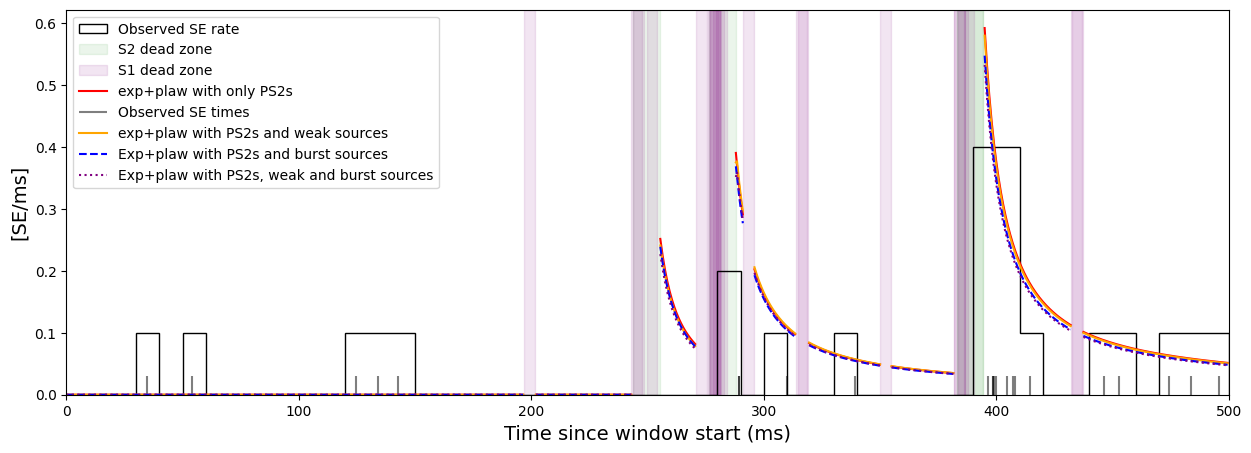

  Zoom region: 0.5 - 1.0 seconds within window
running cdf_plot


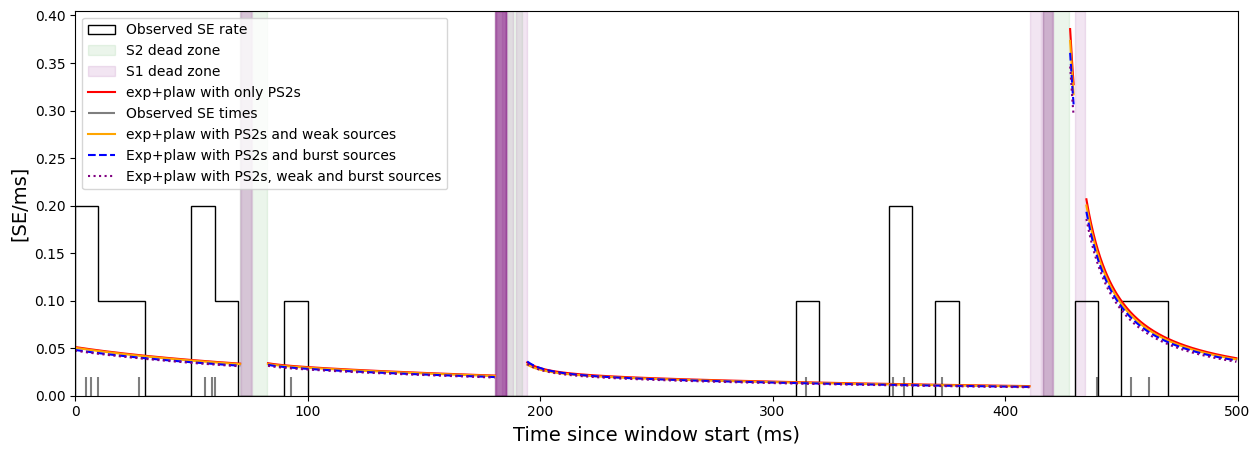

  Zoom region: 1.0 - 1.5 seconds within window
running cdf_plot


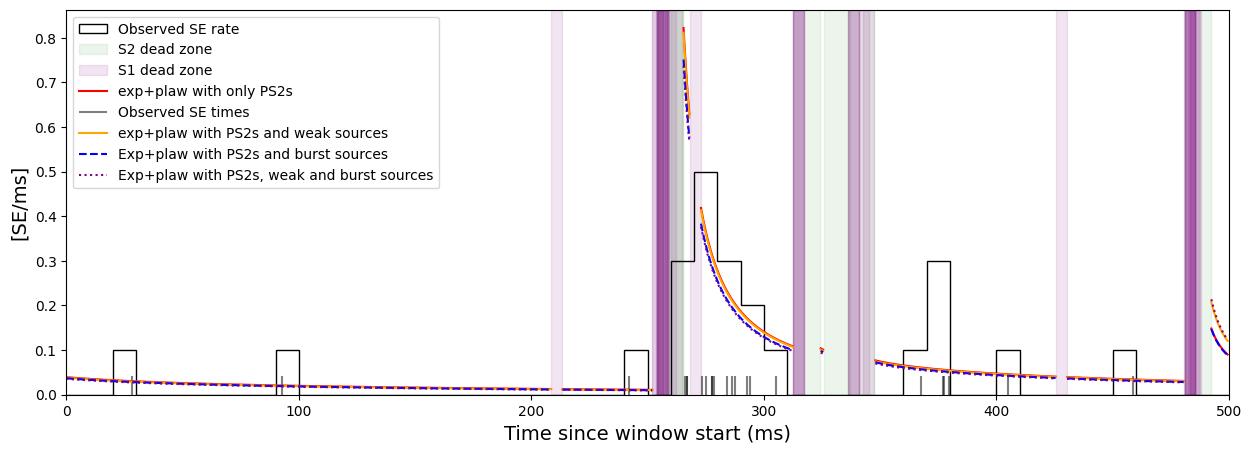

  Zoom region: 1.5 - 2.0 seconds within window
running cdf_plot


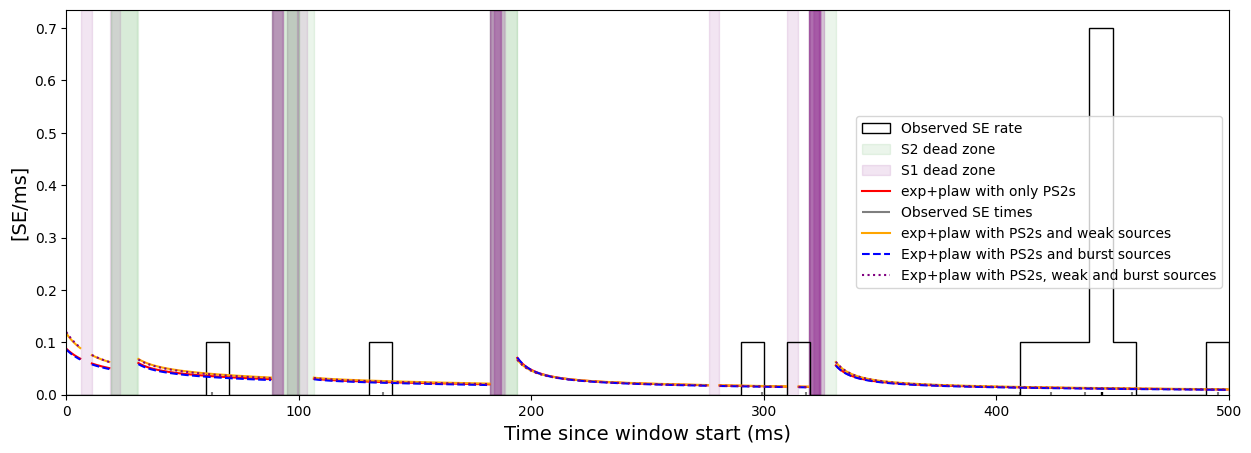

  Zoom region: 2.0 - 2.5 seconds within window
running cdf_plot


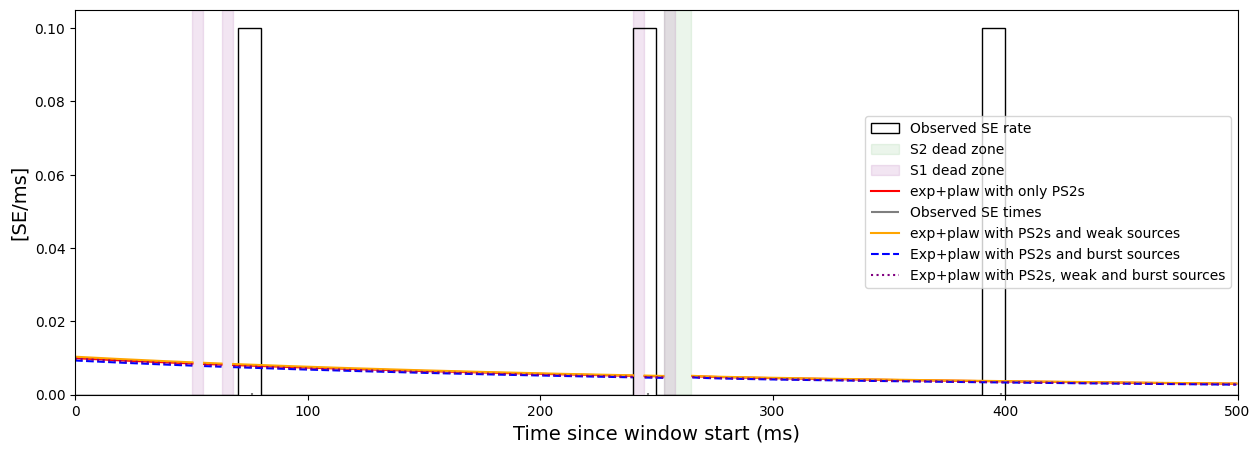

  Zoom region: 2.5 - 3.0 seconds within window
running cdf_plot


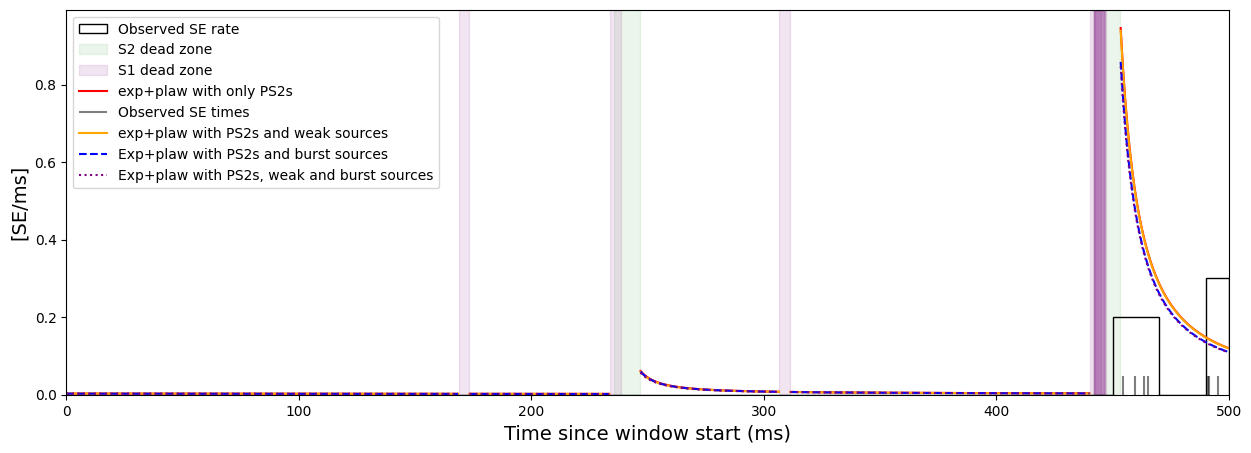

  Zoom region: 3.0 - 3.5 seconds within window
running cdf_plot


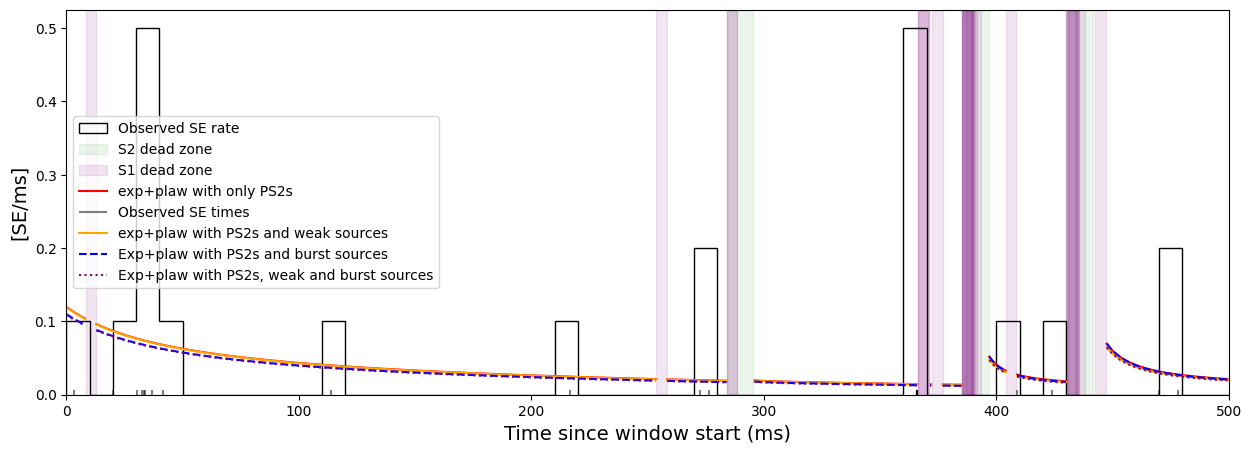

  Zoom region: 3.5 - 4.0 seconds within window
running cdf_plot


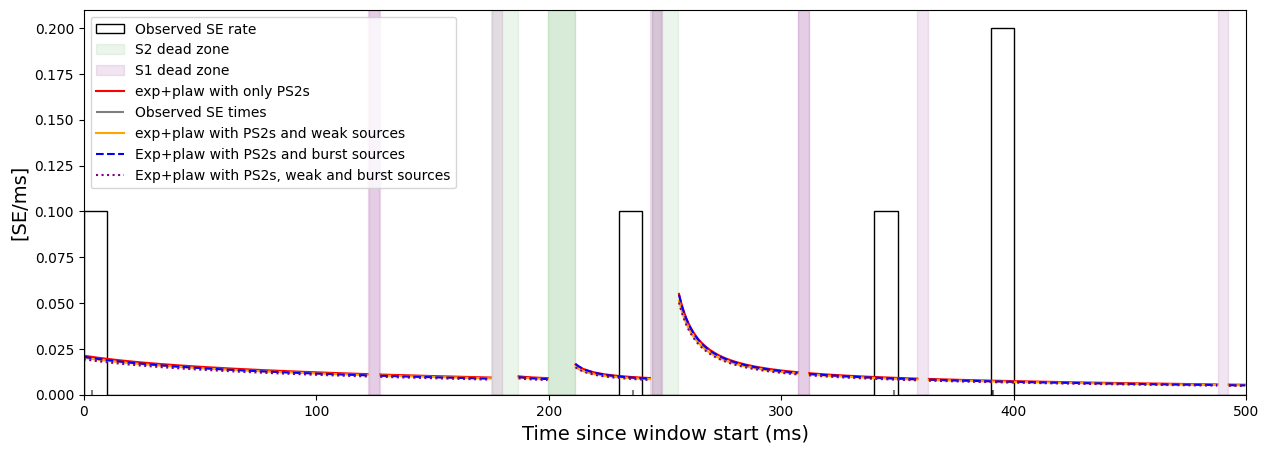

  Zoom region: 4.0 - 4.5 seconds within window
running cdf_plot


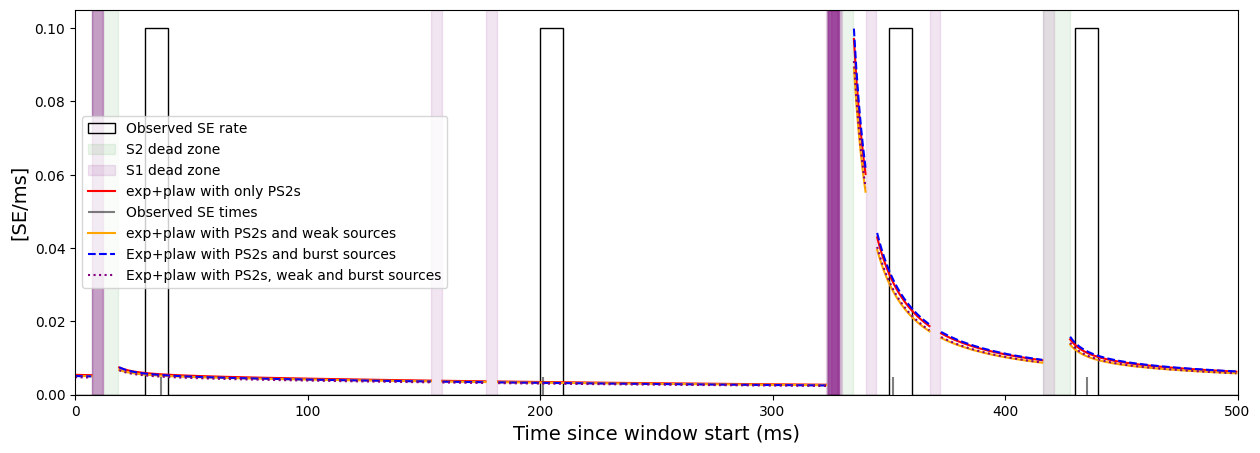

  Zoom region: 4.5 - 5.0 seconds within window
running cdf_plot


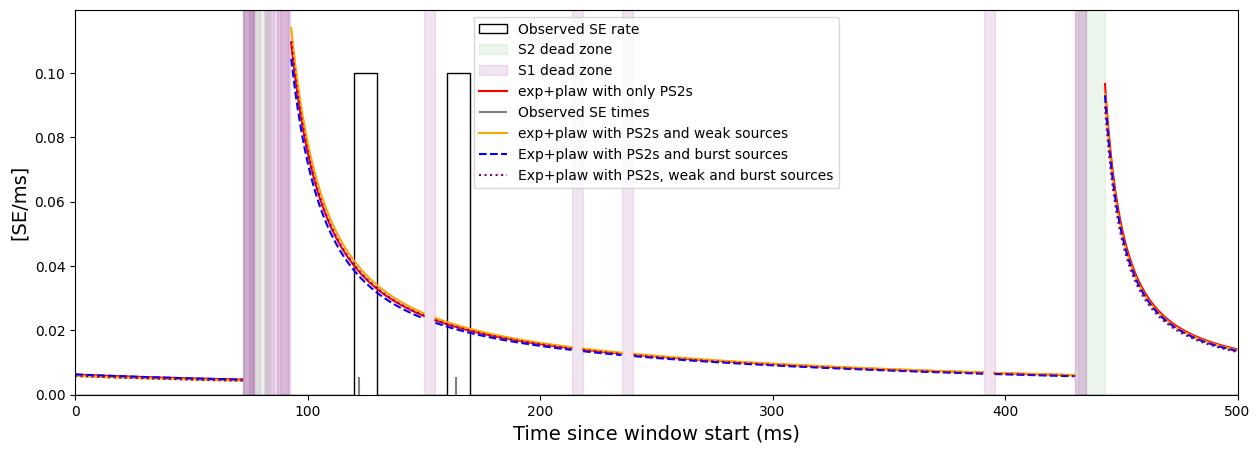

  Zoom region: 5.0 - 5.5 seconds within window
running cdf_plot


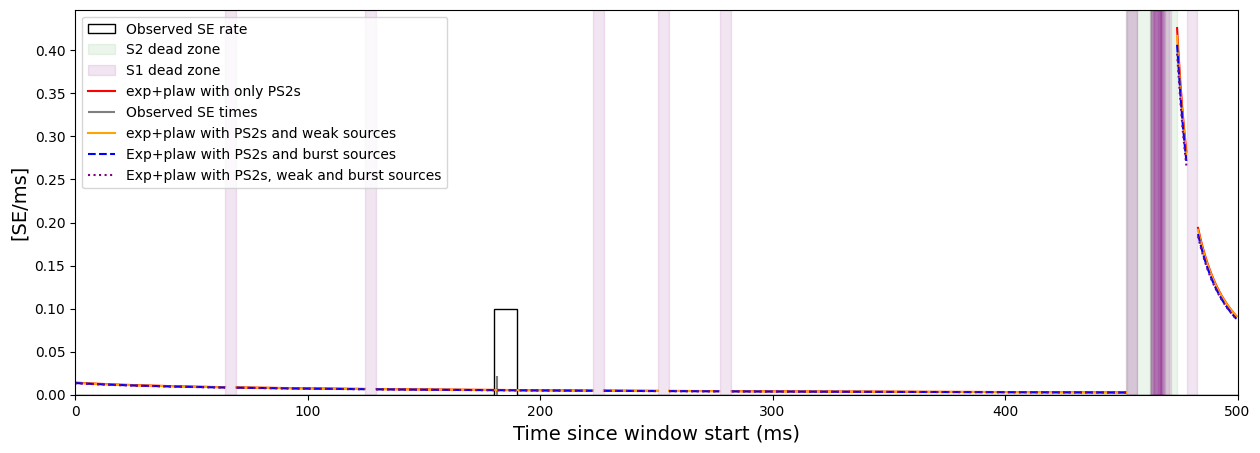

  Zoom region: 5.5 - 6.0 seconds within window
running cdf_plot


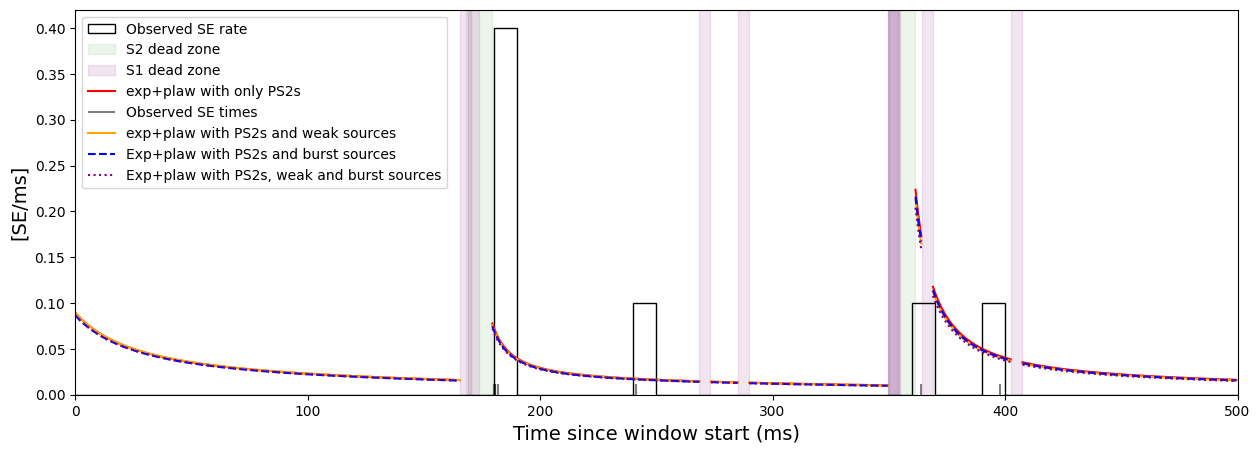

  Zoom region: 6.0 - 6.5 seconds within window
running cdf_plot


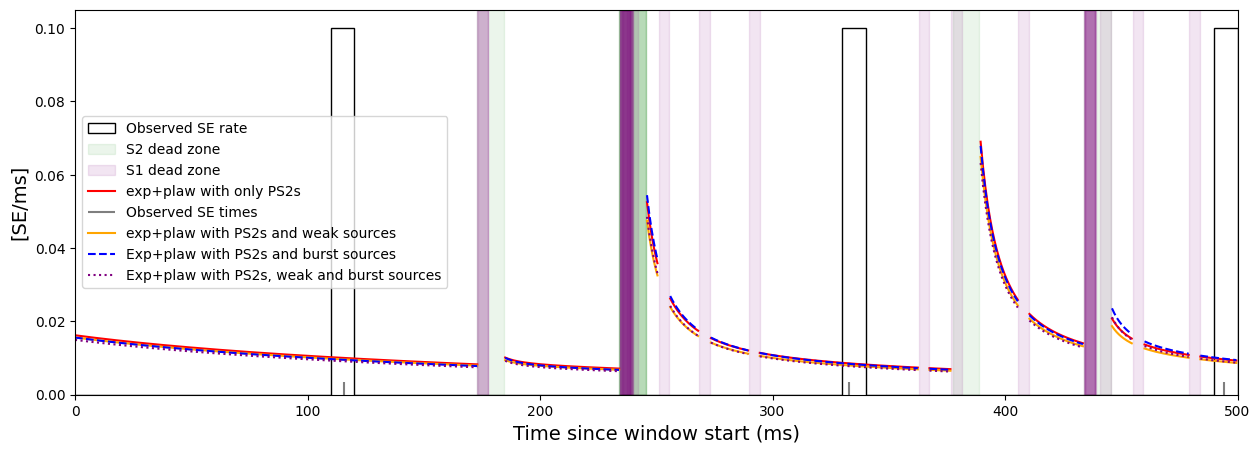

  Zoom region: 6.5 - 7.0 seconds within window
running cdf_plot


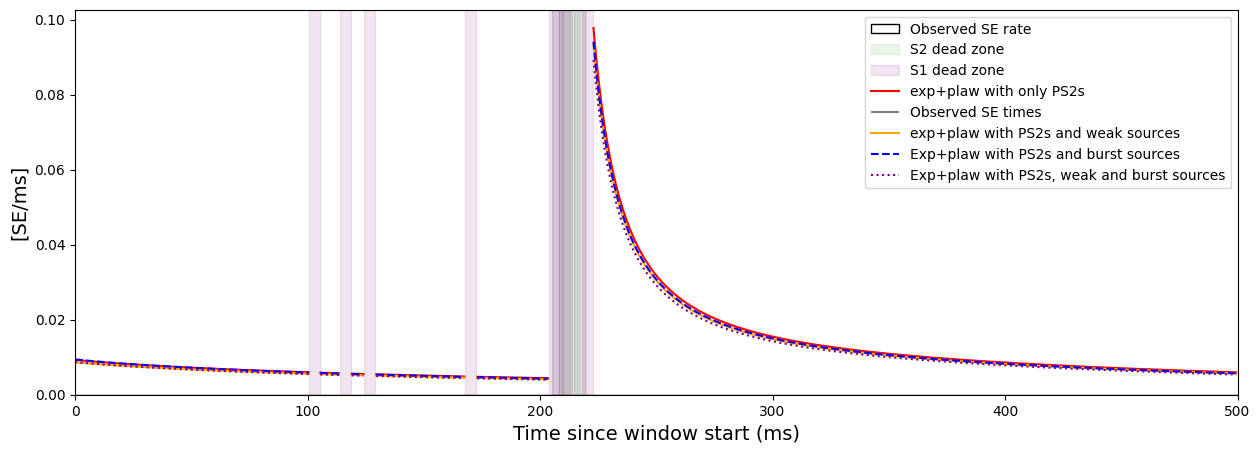

  Zoom region: 7.0 - 7.5 seconds within window
running cdf_plot


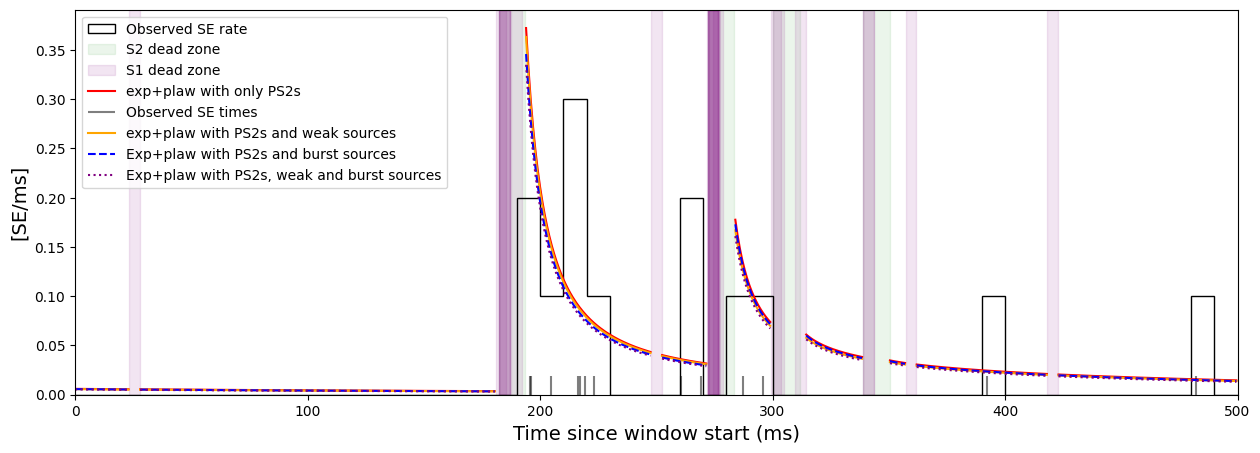

  Zoom region: 7.5 - 8.0 seconds within window
running cdf_plot


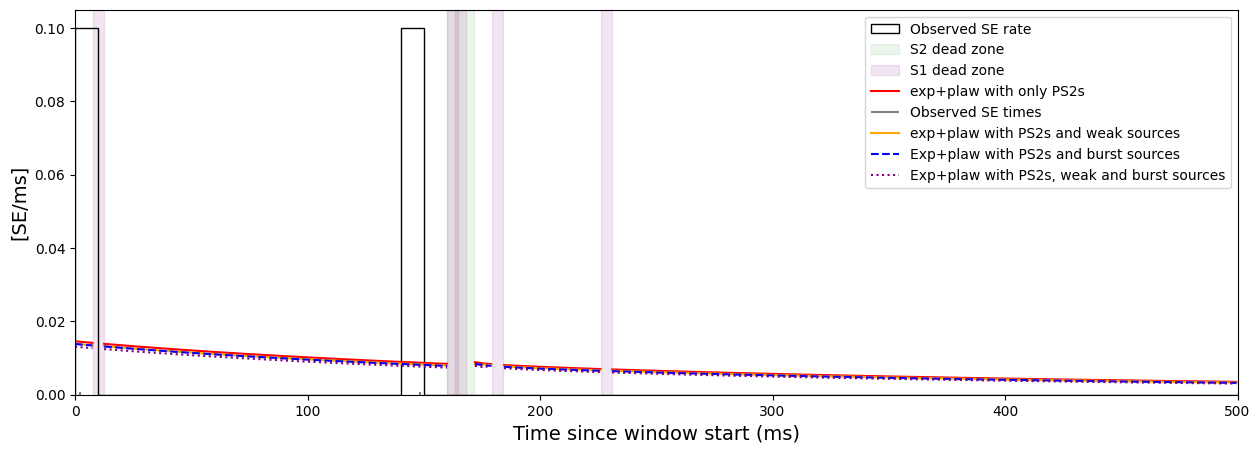

  Zoom region: 8.0 - 8.5 seconds within window
running cdf_plot


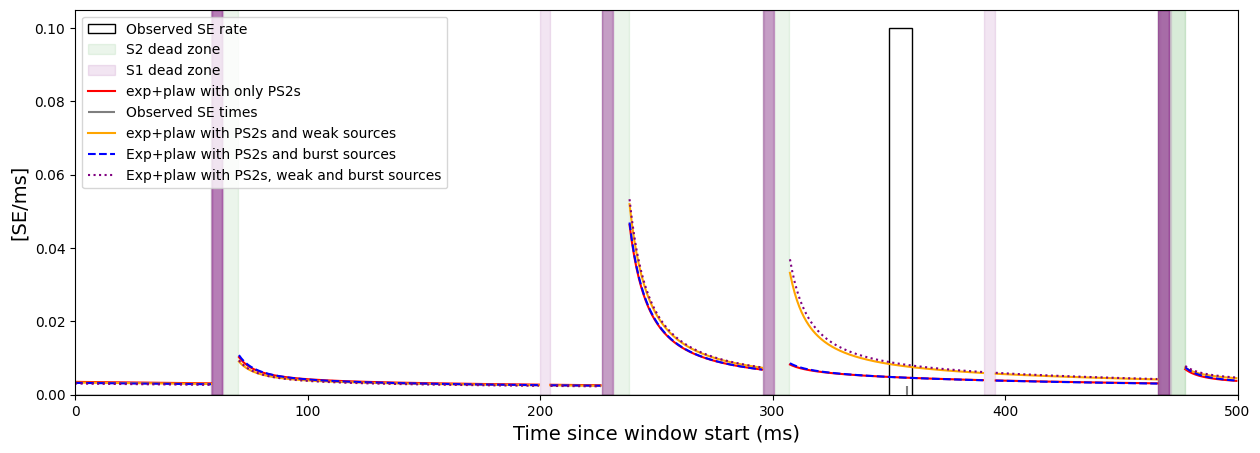

  Zoom region: 8.5 - 9.0 seconds within window
running cdf_plot


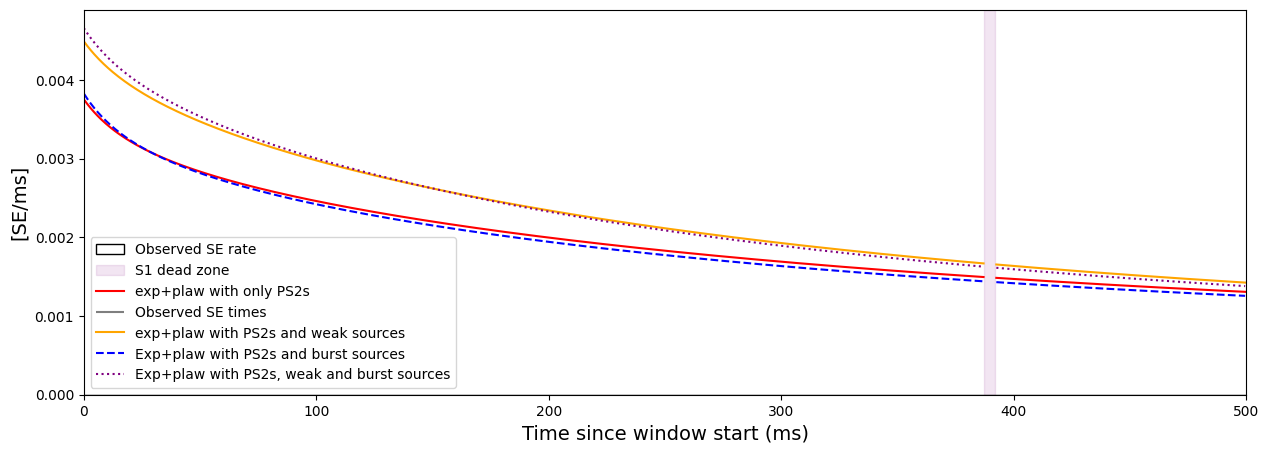

  Zoom region: 9.0 - 9.5 seconds within window
running cdf_plot


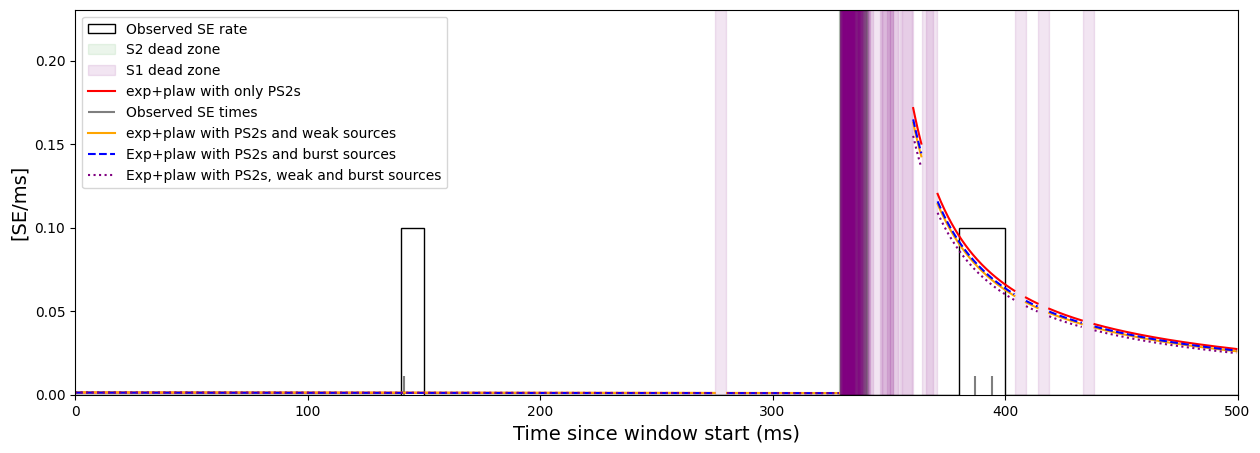

  Zoom region: 9.5 - 10.0 seconds within window
running cdf_plot


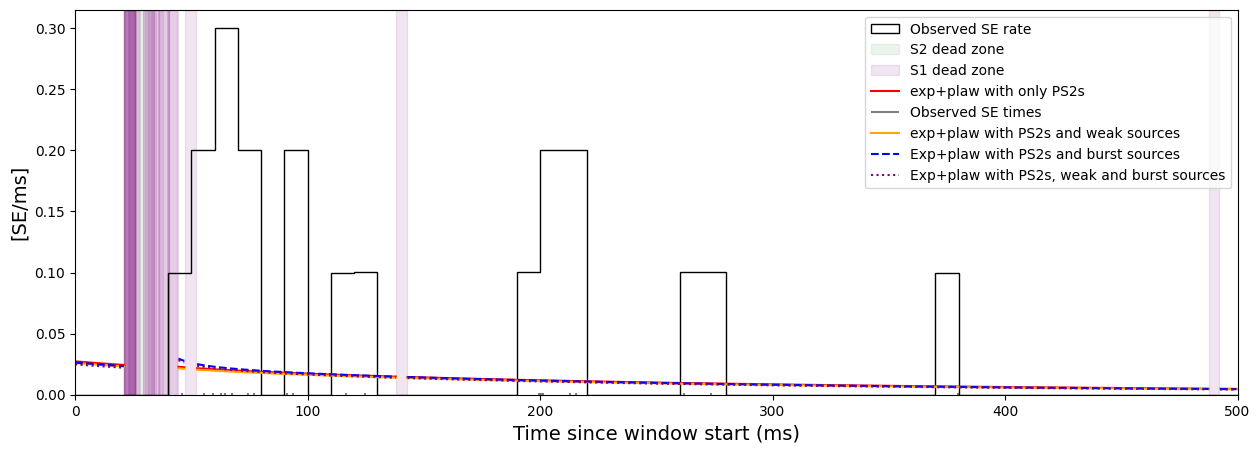

  Zoom region: 10.0 - 10.5 seconds within window
running cdf_plot


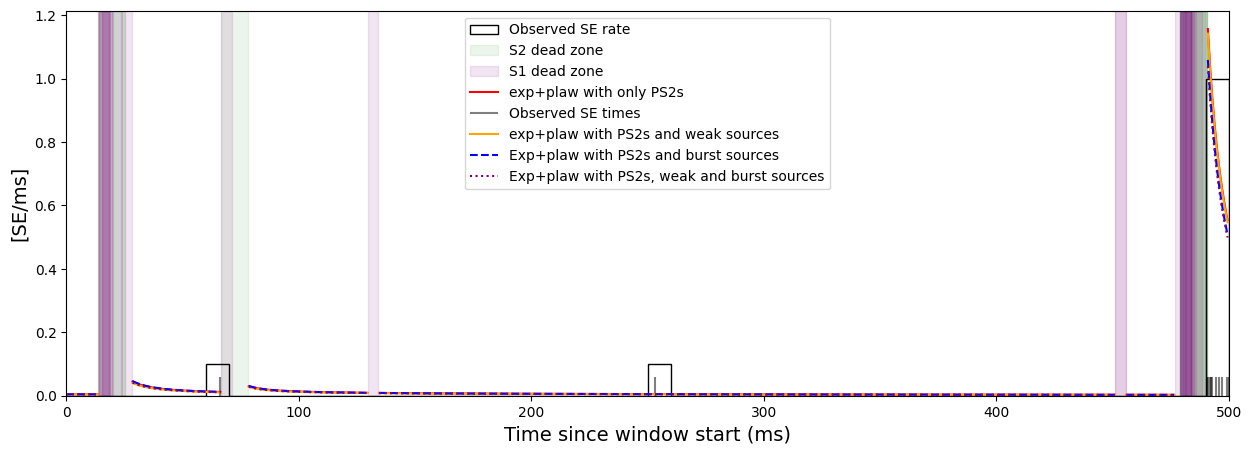

  Zoom region: 10.5 - 11.0 seconds within window
running cdf_plot


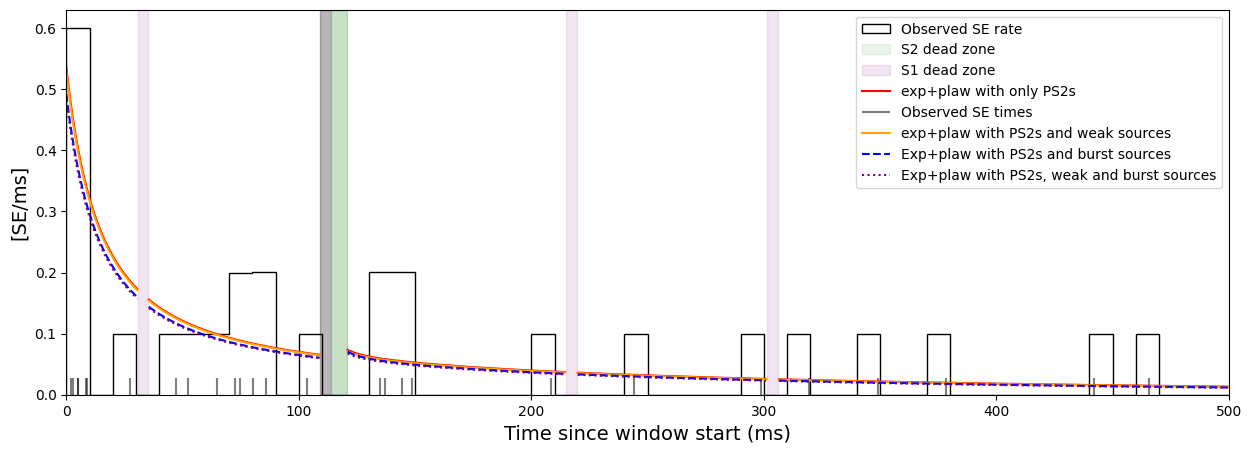

  Zoom region: 11.0 - 11.5 seconds within window
running cdf_plot


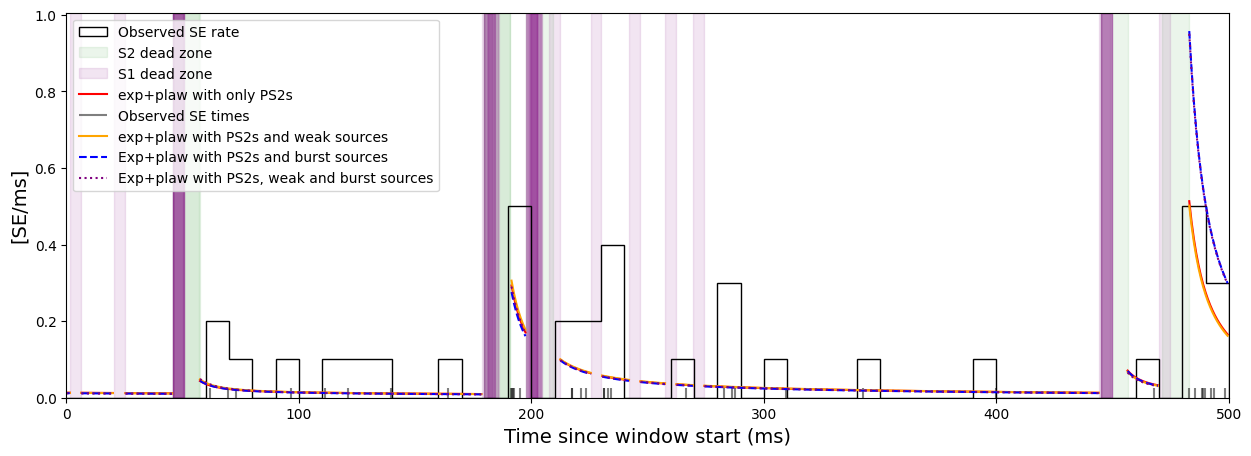

  Zoom region: 11.5 - 12.0 seconds within window
running cdf_plot


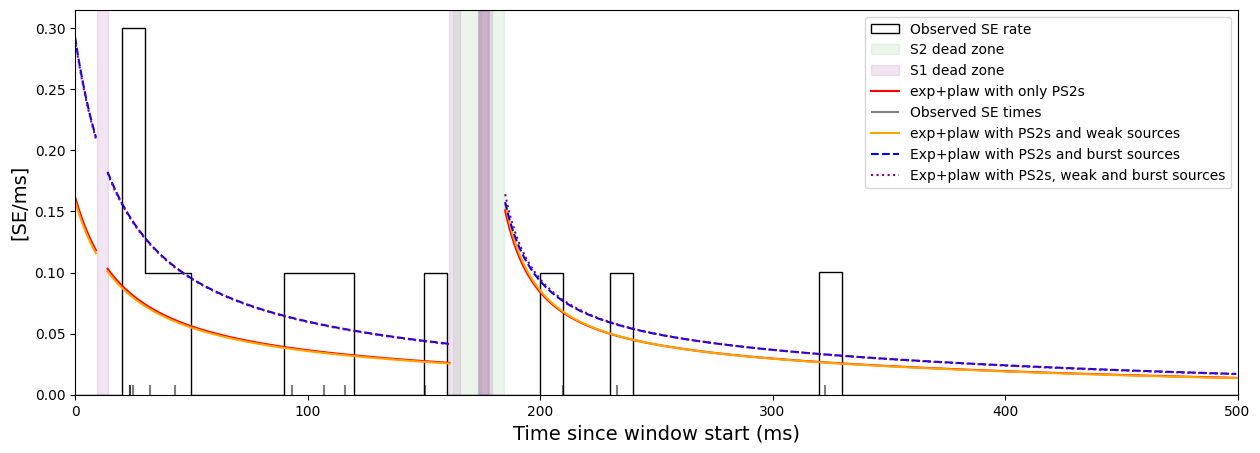

  Zoom region: 12.0 - 12.5 seconds within window
running cdf_plot


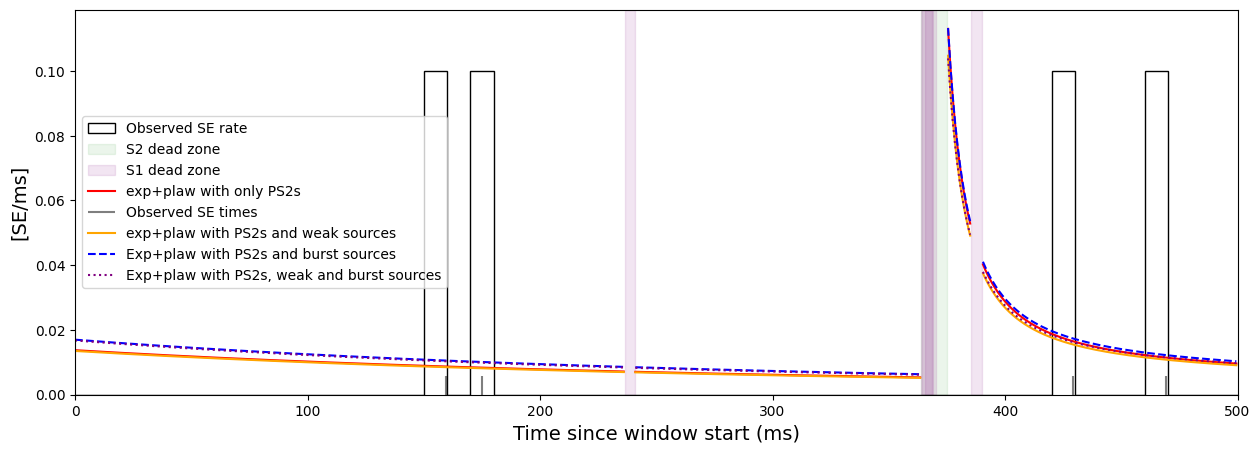

  Zoom region: 12.5 - 13.0 seconds within window
running cdf_plot


SystemError: CPUDispatcher(<function _weak_source_like_pdf_basic_consistent at 0x7be15a4d79c0>) returned a result with an exception set

In [391]:
source_like = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
]

burst_source = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] > 5)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [20, 271, 272, 273])
]

strong_burst_source = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
        & (debug["all_DEs_before_prompt"]["range_50p_area"] / 1e6 > 0.01)
        & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
    )
]

weak_sources = burst_source[
    ~np.isin(burst_source["time"], strong_burst_source["time"])
]

#pS2s = pS2s[np.isin(pS2s['subtype'], [22, 25, 262])]
run_duration = (runs_df.iloc[0]['end'].value - runs_df.iloc[0]['start'].value)/1e9

window_size = 92.766 #seconds
base_width = 0.5 #seconds
margin = 3 #seconds

usable_start = margin
usable_end = run_duration - margin
usable_duration = usable_end - usable_start

n_windows = int(np.ceil(usable_duration / window_size))

results_list = []
values_list = []
cov_list = []
total_rate_list = []
diff_rate_list = []


for i in range(n_windows):

    start_sec = usable_start + i * window_size
    end_sec = min(start_sec + window_size, usable_end)

    if end_sec <= start_sec:
        break

    print(f"\n  window: {start_sec} - {end_sec} seconds")
    results_ps2_only, values_ps2_only, cov_ps2_only, total_ps2_only, diff_ps2_only = mod2.time_fitting(runs_df.iloc[0], pS2s, weak_sources, strong_burst_source,
                                                                                                       DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), history = 5.0, model = 'exp_additive_ps2')

    results_ps2_weak, values_ps2_weak, cov_ps2_weak, total_ps2_weak, diff_ps2_weak = mod2.time_fitting(runs_df.iloc[0], pS2s, weak_sources, strong_burst_source,
                                                                                                       DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), history = 5.0, model = 'exp_additive_ps2_weak')

    results_ps2_burst, values_ps2_burst, cov_ps2_burst, total_ps2_burst, diff_ps2_burst = mod2.time_fitting(runs_df.iloc[0], pS2s,
                                                                                                weak_sources, strong_burst_source,
                                                                                                DEs, S1s['time_since_start'],
                                                                                                seconds_range = (start_sec, end_sec),
                                                                                                history = 5.0,
                                                                                                model = 'exp_additive_ps2_burst')

    results_ps2_burst_weak, values_ps2_burst_weak, cov_ps2_burst_weak, total_ps2_burst_weak, diff_ps2_burst_weak = (mod2.time_fitting
    (runs_df.iloc[0], pS2s,weak_sources,strong_burst_source,DEs,S1s['time_since_start'],seconds_range = (start_sec,end_sec),history =
    5.0, model ='exp_additive_ps2_burst_weak'))


    results_list.append([results_ps2_only, results_ps2_weak, results_ps2_burst, results_ps2_burst_weak])
    values_list.append([values_ps2_only, values_ps2_weak, values_ps2_burst, values_ps2_burst_weak])
    cov_list.append([cov_ps2_only, cov_ps2_weak, cov_ps2_burst, cov_ps2_burst_weak])
    total_rate_list.append([total_ps2_only, total_ps2_weak, total_ps2_burst, total_ps2_burst_weak])
    diff_rate_list.append([diff_ps2_only, diff_ps2_weak, diff_ps2_burst, diff_ps2_burst_weak])

    pS2s_region_new = pS2s[(pS2s['time_since_start'] >= start_sec*1e3) & (pS2s['time_since_start'] <= end_sec*1e3)]
    DEs_region_new = DEs[(DEs['time_since_start'] >= start_sec*1e3) & (DEs['time_since_start'] <= end_sec*1e3)]
    S1_region = S1s[(S1s['time_since_start'] >= start_sec*1e3) & (S1s['time_since_start'] <= end_sec*1e3)]
    weak_sources_new = weak_sources[(weak_sources['time_since_start'] >= start_sec*1e3) & (weak_sources['time_since_start'] <= end_sec*1e3)]
    strong_burst_source_new = strong_burst_source[(strong_burst_source['time_since_start'] >= start_sec*1e3) & (strong_burst_source['time_since_start'] <= end_sec*1e3)]

    available_width = end_sec - start_sec
    n_zooms = int(np.ceil(available_width / base_width))

    for j in range(n_zooms):
        start_zoom = j*base_width
        if start_zoom >= available_width:
            break

        zoom_width = min(base_width, available_width - start_zoom)
        if zoom_width < 0:
            break

        plot_zoom = (start_zoom, zoom_width)
        print(f"  Zoom region: {start_zoom:.1f} - {start_zoom + zoom_width:.1f} seconds within window")
        print("running cdf_plot")

        zoom_start_abs_ms = start_sec * 1e3 + start_zoom * 1e3
        zoom_stop_abs_ms = zoom_start_abs_ms + zoom_width * 1e3

        se_zoom_times = DEs_region_new[
        (DEs_region_new["time_since_start"] >= zoom_start_abs_ms)
        & (DEs_region_new["time_since_start"] <= zoom_stop_abs_ms)]["time_since_start"]

        resolution_ms = 10
        bins = np.arange(zoom_start_abs_ms, zoom_stop_abs_ms + resolution_ms, resolution_ms)
        hist, _ = np.histogram(se_zoom_times, bins=bins)

        _, p_ps2_only, t_abs, _ = mod2.cdf_plot(
        pS2s_region_new,
        DEs_region_new,
        weak_sources_new,
        strong_burst_source_new,
        S1_region['time_since_start'],
        values_ps2_only,
        cov_ps2_only,
        model='exp_additive_ps2',
        label='exp+plaw with only PS2s',
        color='blue',
        seconds_range=(start_sec, end_sec),
        plot_zoom=plot_zoom,
        extra_models=[
        {
            "model": "exp_additive_ps2_weak",
            "values": values_ps2_weak,
            "cov": cov_ps2_weak,
            "label": "exp+plaw with PS2s and weak sources",
            "color": "orange",
            "linestyle": "-"
        },
        {
        "model": "exp_additive_ps2_burst",
        "values": values_ps2_burst,
        "cov": cov_ps2_burst,
        "label": "Exp+plaw with PS2s and burst sources",
        "color": "blue",
        "linestyle": "--"
        },
        {
        "model": "exp_additive_ps2_burst_weak",
        "values": values_ps2_burst_weak,
        "cov": cov_ps2_burst_weak,
        "label": "Exp+plaw with PS2s, weak and burst sources",
        "color": "purple",
        "linestyle": ":"
        }],
        show_model_errors= False
        )


In [323]:
models = [
    "ps2_only",
    "ps2_weak",
    "ps2_burst",
    "ps2_burst_weak",
]

tables = {}

for i, window_results in enumerate(results_list):
    start_sec = usable_start + i * window_size
    end_sec = min(start_sec + window_size, usable_end)

    window_label = f"{start_sec:.2f}-{end_sec:.2f} s"

    for model_name, df in zip(models, window_results):
        tables[(window_label, model_name)] = (
            df.set_index("Parameter")["Value"]
        )

comparison = pd.concat(tables, axis=1)

rows = [
    "s",
    "q_weak",
    "q_burst",
    "k",
    "BIC",
]
display(comparison.loc[rows])

0.01-2.01 s                                        2.01-4.01 s  \
             ps2_only    ps2_weak   ps2_burst ps2_burst_weak    ps2_only   
Parameter                                                                  
s            0.006483    0.000001    0.011921       0.000003    0.031574   
q_weak              0    0.000999           0       0.000753           0   
q_burst             0           0    0.013185       0.013095           0   
k                 0.0         0.0         0.0            0.0    0.001973   
BIC        104.930484  106.747649  102.612921     104.347421  443.950418   

                                                 4.01-6.01 s              ...  \
             ps2_weak   ps2_burst ps2_burst_weak    ps2_only    ps2_weak  ...   
Parameter                                                                 ...   
s            0.004955    0.011496       0.004984    0.068627     0.06939  ...   
q_weak       0.000982           0       0.000835           0         0.0  ...   
q_burst             0    0.192896       0.123112           0           0  ...   
k            0.002035         0.0            0.0         0.0         0.0  ...   
BIC        445.841542  445.891565     449.305212  404.784384  408.696267  ...   

          88.01-90.01 s                90.01-92.01 s                          \
              ps2_burst ps2_burst_weak      ps2_only    ps2_weak   ps2_burst   
Parameter                                                                      
s              0.001503       0.000004      1.210732    1.209413    1.111138   
q_weak                0       0.001129             0         0.0           0   
q_burst         0.08968       0.073301             0           0    0.034031   
k              0.001649       0.001175           0.0         0.0         0.0   
BIC          273.098318     271.365329    385.556972  389.469004  389.388419   

                         92.01-92.76 s                                         
          ps2_burst_weak      ps2_only    ps2_weak   ps2_burst ps2_burst_weak  
Parameter                                                                      
s               1.111489      1.662768    0.151815    0.010619       0.182715  
q_weak               0.0             0         0.0           0            0.0  
q_burst         0.034039             0           0         0.0            0.0  
k                    0.0           0.0         0.0         0.0            0.0  
BIC             393.3004     173.36459  176.419507  170.719565     179.716377  

[5 rows x 188 columns]

In [324]:
rows = ["n", "tau", "f_exp", "tmin", "c", "d"]
display(comparison.loc[rows])

0.01-2.01 s                                     2.01-4.01 s  \
             ps2_only  ps2_weak  ps2_burst ps2_burst_weak    ps2_only   
Parameter                                                               
n            1.261215  1.261944        1.2       1.200001    2.707592   
tau          5.156424  8.124222  84.658094      91.671129  200.467462   
f_exp             0.1       0.1   0.999991       0.999996    0.758863   
tmin             11.5      11.5       11.5           11.5        11.5   
c            4.999989   4.82402   0.000012       0.637806    0.637774   
d             4.06343 -1.532707   3.567302       1.082984    4.022726   

                                                 4.01-6.01 s              ...  \
             ps2_weak   ps2_burst ps2_burst_weak    ps2_only    ps2_weak  ...   
Parameter                                                                 ...   
n            2.687401    2.988329        2.87395    1.683348    1.683609  ...   
tau        212.029482  199.318993     215.559658  544.434323  544.072864  ...   
f_exp        0.750709    0.791758       0.785365    0.689255    0.688968  ...   
tmin             11.5        11.5           11.5        11.5        11.5  ...   
c            1.935643    0.670869       1.906322    1.842531     1.84418  ...   
d            4.999873     4.61503       4.999837    2.798686    2.789465  ...   

          88.01-90.01 s                90.01-92.01 s                         \
              ps2_burst ps2_burst_weak      ps2_only    ps2_weak  ps2_burst   
Parameter                                                                     
n              4.283373       2.533892      1.569188    1.570578   1.790623   
tau           74.942028      83.383688    157.832667  157.248123  148.27689   
f_exp          0.999997       0.999999      0.483513    0.484505   0.617294   
tmin               11.5           11.5          11.5        11.5       11.5   
c               1.01204       0.684338      0.739857    0.739622   0.756042   
d              4.999933       1.101315      1.205469    1.206408   1.213443   

                         92.01-92.76 s                                      
          ps2_burst_weak      ps2_only  ps2_weak  ps2_burst ps2_burst_weak  
Parameter                                                                   
n                1.79183      1.785391  1.826762   1.726516       1.826906  
tau           148.082289      0.200195       0.2  34.493968            0.2  
f_exp           0.617615      0.116778  0.964329   0.807052        0.97029  
tmin                11.5          11.5      11.5       11.5           11.5  
c               0.755654      0.382596  0.876247   0.429643       0.875405  
d               1.213437      1.617186  4.999992   4.999977       4.999274  

[6 rows x 188 columns]

In [91]:
values_list[-1][3]

<ValueView s=0.7982068166942411 n=1.456 tau=241.0 f_exp=0.29 tmin=11.5 c=0.775 d=1.5 q_weak=0.0005041439078188021 q_burst=0.011886209455828422 k=0.0>

In [262]:
window_start_ms = 82.47 * 1e3
window_stop_ms = 92.76 * 1e3
mu_q_ps2_only, _, _ = expected_count_gap(
    mod2.multi_exp_additive_three_source_wrap,
    values_list[-1][0],
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = weak_sources,
    burst_source = strong_burst_source
)
mu_q_ps2_weak, _, _ = expected_count_gap(
    mod2.multi_exp_additive_three_source_wrap,
    values_list[-1][1],
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = weak_sources,
    burst_source = strong_burst_source
)
mu_q_ps2_burst, _, _ = expected_count_gap(
    mod2.multi_exp_additive_three_source_wrap,
    values_list[-1][2],
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = weak_sources,
    burst_source = strong_burst_source
)
mu_q_ps2_burst_weak, _, _ = expected_count_gap(
    mod2.multi_exp_additive_three_source_wrap,
    values_list[-1][3],
    pS2s,
    S1s["time_since_start"],
    window_start_ms,
    window_stop_ms,
    84500,
    85000,
    source_like = weak_sources,
    burst_source = strong_burst_source
)

In [89]:
print(mu_q_ps2_only, mu_q_ps2_weak, mu_q_ps2_burst, mu_q_ps2_burst_weak)

1.9766744033106027 1.9922247561490425 2.1926219777559472 2.2107307683661013


In [95]:
len(values_list)
len(np.arange(0, 92700, 11000))

9

In [131]:
values_list

[[<ValueView s=1.0093902917868853 n=1.456 tau=241.0 f_exp=0.29 tmin=11.5 c=0.775 d=1.5 q_weak=0.0 q_burst=0.0 k=7.84361853048513e-06>,
  <ValueView s=1.009057676092693 n=1.456 tau=241.0 f_exp=0.29 tmin=11.5 c=0.775 d=1.5 q_weak=4.109415832360269e-09 q_burst=0.0 k=4.391706108412916e-06>,
  <ValueView s=0.9989276116164806 n=1.456 tau=241.0 f_exp=0.29 tmin=11.5 c=0.775 d=1.5 q_weak=0.0 q_burst=0.007331074761658521 k=3.4411370777062515e-09>,
  <ValueView s=0.998840455486848 n=1.456 tau=241.0 f_exp=0.29 tmin=11.5 c=0.775 d=1.5 q_weak=1.4860575194442643e-10 q_burst=0.007338963558937086 k=3.0447207258134552e-09>]]

In [327]:
from sklearn.metrics import mean_poisson_deviance
import numpy as np
import pandas as pd

sub_bin_ms = 200.0
eps = 1e-12

model_names = ["ps2", "ps2_weak", "ps2_burst", "ps2_burst_weak"]

rows = []

DE_times = np.asarray(DEs["time_since_start"], dtype=float)

window_list = []
for i in range(int(np.ceil(92.766 / 2))):
    window_list.append((i * 2, min(i * 2 + 2, 92.766)))

for i, (start_sec, end_sec) in enumerate(window_list):
    fit_start_ms = start_sec * 1000
    fit_stop_ms = end_sec * 1000

    source_start_ms = max(0.0, fit_start_ms - history_ms)

    # Source catalogues used for this fitted window
    pS2_region = pS2s[
        (pS2s["time_since_start"] >= source_start_ms)
        & (pS2s["time_since_start"] <= fit_stop_ms)
    ]

    weak_region = weak_sources[
        (weak_sources["time_since_start"] >= source_start_ms)
        & (weak_sources["time_since_start"] <= fit_stop_ms)
    ]

    burst_region = strong_burst_source[
        (strong_burst_source["time_since_start"] >= source_start_ms)
        & (strong_burst_source["time_since_start"] <= fit_stop_ms)
    ]

    s1_times = np.asarray(S1s["time_since_start"], dtype=float)
    s1_region = s1_times[
        (s1_times >= source_start_ms)
        & (s1_times <= fit_stop_ms)
    ]

    sub_edges = np.arange(fit_start_ms, fit_stop_ms + sub_bin_ms, sub_bin_ms)

    for a, b in zip(sub_edges[:-1], sub_edges[1:]):
        b = min(b, fit_stop_ms)

        # Observed sub-bin count
        N_obs = np.sum((DE_times >= a) & (DE_times < b))

        row = {
            "fit_window_i": i,
            "fit_window": f"{start_sec:.3f}-{end_sec:.3f}s",
            "sub_start_ms": a,
            "sub_stop_ms": b,
            "sub_bin": f"{a/1000:.3f}-{b/1000:.3f}s",
            "N_obs": N_obs,
        }

        # Predicted sub-bin count for each model
        for j, name in enumerate(model_names):
            mu, _, _ = expected_count_gap(
                mod2.multi_exp_additive_three_source_wrap,
                values_list[i][j],
                pS2_region,
                s1_region,
                gap_start_ms=a,
                gap_stop_ms=b,
                source_like=weak_region,
                burst_source=burst_region,
            )

            row[f"mu_{name}"] = mu

        rows.append(row)

subbin_df = pd.DataFrame(rows)
display(subbin_df)

,fit_window_i,fit_window,sub_start_ms,sub_stop_ms,sub_bin,N_obs,mu_ps2,mu_ps2_weak,mu_ps2_burst,mu_ps2_burst_weak
0,0,0.000-2.000s,0.0,200.0,0.000-0.200s,0,0.026147,0.005912,0.000187,0.004763
1,0,0.000-2.000s,200.0,400.0,0.200-0.400s,1,0.548379,0.593282,0.519280,0.493836
2,0,0.000-2.000s,400.0,600.0,0.400-0.600s,0,0.288493,0.272713,0.435360,0.455944
3,0,0.000-2.000s,600.0,800.0,0.600-0.800s,0,0.266766,0.085586,0.297770,0.051033
4,0,0.000-2.000s,800.0,1000.0,0.800-1.000s,3,4.539908,5.006357,4.716559,4.690814
...,...,...,...,...,...,...,...,...,...,...
459,45,90.000-92.000s,91800.0,92000.0,91.800-92.000s,10,8.068157,8.064030,8.293005,8.288260
460,46,92.000-92.766s,92000.0,92200.0,92.000-92.200s,6,5.382459,5.675320,3.639537,5.675853
461,46,92.000-92.766s,92200.0,92400.0,92.200-92.400s,21,18.682677,18.420276,21.614725,18.412874
462,46,92.000-92.766s,92400.0,92600.0,92.400-92.600s,0,2.036594,1.979187,1.074572,1.978830


In [328]:
summary_rows = []

N = subbin_df["N_obs"].to_numpy(dtype=float)

for name in model_names:
    mu = subbin_df[f"mu_{name}"].to_numpy(dtype=float)
    mu = np.maximum(mu, eps)

    mpd = mean_poisson_deviance(N, mu)
    total_D = mpd * len(N)

    summary_rows.append({
        "model": name,
        "mean_poisson_deviance": mpd,
        "total_poisson_deviance": total_D,
        "total_expected": np.sum(mu),
        "total_observed": np.sum(N),
    })

deviance_summary = pd.DataFrame(summary_rows)
display(deviance_summary.sort_values("mean_poisson_deviance"))

,model,mean_poisson_deviance,total_poisson_deviance,total_expected,total_observed
3,ps2_burst_weak,1.230631,571.012728,2441.722451,2444.0
2,ps2_burst,1.248996,579.534360,2440.526432,2444.0
1,ps2_weak,1.468047,681.173938,2439.897867,2444.0
0,ps2,1.509311,700.320264,2438.128421,2444.0


In [329]:
for name in model_names:
    mu = subbin_df[f"mu_{name}"].to_numpy(dtype=float)
    N = subbin_df["N_obs"].to_numpy(dtype=float)
    mask = mu > 0
    pull = np.full_like(mu, np.nan, dtype=float)
    pull[mask] = (mu[mask] - N[mask]) / mu[mask]
    subbin_df[f"D_{name}"] = poisson_deviance(N, mu)
    subbin_df[f"pull_{name}"] = pull

display(subbin_df)

,fit_window_i,fit_window,sub_start_ms,sub_stop_ms,sub_bin,N_obs,mu_ps2,mu_ps2_weak,mu_ps2_burst,mu_ps2_burst_weak,D_ps2,pull_ps2,D_ps2_weak,pull_ps2_weak,D_ps2_burst,pull_ps2_burst,D_ps2_burst_weak,pull_ps2_burst_weak
0,0,0.000-2.000s,0.0,200.0,0.000-0.200s,0,0.026147,0.005912,0.000187,0.004763,0.052293,1.000000,0.011825,1.000000,0.000374,1.000000,0.009525,1.000000
1,0,0.000-2.000s,200.0,400.0,0.200-0.400s,1,0.548379,0.593282,0.519280,0.493836,0.298335,-0.823556,0.230734,-0.685538,0.349184,-0.925742,0.398775,-1.024963
2,0,0.000-2.000s,400.0,600.0,0.400-0.600s,0,0.288493,0.272713,0.435360,0.455944,0.576987,1.000000,0.545426,1.000000,0.870719,1.000000,0.911889,1.000000
3,0,0.000-2.000s,600.0,800.0,0.600-0.800s,0,0.266766,0.085586,0.297770,0.051033,0.533532,1.000000,0.171172,1.000000,0.595540,1.000000,0.102066,1.000000
4,0,0.000-2.000s,800.0,1000.0,0.800-1.000s,3,4.539908,5.006357,4.716559,4.690814,0.594049,0.339194,0.940137,0.400762,0.718315,0.363943,0.699665,0.360452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,45,90.000-92.000s,91800.0,92000.0,91.800-92.000s,10,8.068157,8.064030,8.293005,8.288260,0.429514,-0.239440,0.431493,-0.240075,0.329464,-0.205836,0.331421,-0.206526
460,46,92.000-92.766s,92000.0,92200.0,92.000-92.200s,6,5.382459,5.675320,3.639537,5.675853,0.068288,-0.114732,0.018230,-0.057209,1.277910,-0.648561,0.018169,-0.057110
461,46,92.000-92.766s,92200.0,92400.0,92.200-92.400s,21,18.682677,18.420276,21.614725,18.412874,0.276234,-0.124036,0.345510,-0.140048,0.017651,0.028440,0.347587,-0.140506
462,46,92.000-92.766s,92400.0,92600.0,92.400-92.600s,0,2.036594,1.979187,1.074572,1.978830,4.073188,1.000000,3.958373,1.000000,2.149144,1.000000,3.957659,1.000000


In [330]:
for name in model_names:
    print("\nWorst sub-bins for", name)
    display(
        subbin_df.sort_values(f"D_{name}", ascending=False)[
            [
                "fit_window",
                "sub_bin",
                "N_obs",
                f"mu_{name}",
                f"D_{name}",
            ]
        ].head(10)
    )
    print("\nBest sub-bins for", name)
    display(
        subbin_df.sort_values(f"D_{name}", ascending = True)[[
            "fit_window",
            "sub_bin",
            "N_obs",
            f"mu_{name}",
            f"D_{name}",
        ]].head(10)
    )


Worst sub-bins for ps2


,fit_window,sub_bin,N_obs,mu_ps2,D_ps2
424,84.000-86.000s,84.800-85.000s,32,5.689813,57.911376
24,4.000-6.000s,4.800-5.000s,13,3.438793,15.453136
197,38.000-40.000s,39.400-39.600s,21,7.922470,14.787356
95,18.000-20.000s,19.000-19.200s,17,5.761069,14.313206
334,66.000-68.000s,66.800-67.000s,22,8.963542,13.433672
170,34.000-36.000s,34.000-34.200s,0,6.464230,12.928460
193,38.000-40.000s,38.600-38.800s,8,1.673827,12.376916
172,34.000-36.000s,34.400-34.600s,31,15.432887,12.109935
444,88.000-90.000s,88.800-89.000s,13,4.312249,11.315233
190,38.000-40.000s,38.000-38.200s,5,15.986910,10.350497



Best sub-bins for ps2


,fit_window,sub_bin,N_obs,mu_ps2,D_ps2
260,52.000-54.000s,52.000-52.200s,5,4.997627,0.000001
355,70.000-72.000s,71.000-71.200s,0,0.000004,0.000007
356,70.000-72.000s,71.200-71.400s,0,0.000004,0.000007
354,70.000-72.000s,70.800-71.000s,0,0.000010,0.000019
111,22.000-24.000s,22.200-22.400s,8,8.020749,0.000054
222,44.000-46.000s,44.400-44.600s,12,12.039585,0.000130
361,72.000-74.000s,72.200-72.400s,2,1.981139,0.000179
12,2.000-4.000s,2.400-2.600s,2,2.042994,0.000911
383,76.000-78.000s,76.600-76.800s,4,4.072148,0.001286
388,76.000-78.000s,77.600-77.800s,4,4.072308,0.001292



Worst sub-bins for ps2_weak


...

,fit_window,sub_bin,N_obs,mu_ps2_burst,D_ps2_burst
356,70.000-72.000s,71.200-71.400s,0,1.222905e-07,2.445810e-07
355,70.000-72.000s,71.000-71.200s,0,1.235211e-07,2.470422e-07
354,70.000-72.000s,70.800-71.000s,0,5.213728e-06,1.042746e-05
260,52.000-54.000s,52.000-52.200s,5,5.008495e+00,1.441647e-05
127,24.000-26.000s,25.400-25.600s,26,2.602894e+01,3.217944e-05
110,22.000-24.000s,22.000-22.200s,17,1.696911e+01,5.618569e-05
46,8.000-10.000s,9.200-9.400s,1,1.008133e+00,6.579345e-05
77,14.000-16.000s,15.400-15.600s,3,2.985049e+00,7.475825e-05
222,44.000-46.000s,44.400-44.600s,12,1.203814e+01,1.209731e-04
412,82.000-84.000s,82.400-82.600s,10,1.003914e+01,1.528257e-04



Worst sub-bins for ps2_burst_weak


,fit_window,sub_bin,N_obs,mu_ps2_burst_weak,D_ps2_burst_weak
24,4.000-6.000s,4.800-5.000s,13,3.441144,15.440066
95,18.000-20.000s,19.000-19.200s,17,5.685207,14.612171
197,38.000-40.000s,39.400-39.600s,21,8.006189,14.513296
193,38.000-40.000s,38.600-38.800s,8,1.561052,13.267410
170,34.000-36.000s,34.000-34.200s,0,6.461520,12.923041
172,34.000-36.000s,34.400-34.600s,31,15.430721,12.114304
334,66.000-68.000s,66.800-67.000s,22,9.462340,12.048480
18,2.000-4.000s,3.600-3.800s,0,5.761260,11.522521
190,38.000-40.000s,38.000-38.200s,5,14.981524,8.989250
176,34.000-36.000s,35.200-35.400s,12,23.535256,6.904283



Best sub-bins for ps2_burst_weak


,fit_window,sub_bin,N_obs,mu_ps2_burst_weak,D_ps2_burst_weak
354,70.000-72.000s,70.800-71.000s,0,0.000008,0.000015
356,70.000-72.000s,71.200-71.400s,0,0.000031,0.000061
99,18.000-20.000s,19.800-20.000s,3,2.986194,0.000064
336,66.000-68.000s,67.200-67.400s,2,2.018279,0.000166
92,18.000-20.000s,18.400-18.600s,11,10.939558,0.000333
361,72.000-74.000s,72.200-72.400s,2,1.972521,0.000381
127,24.000-26.000s,25.400-25.600s,26,25.881739,0.000540
84,16.000-18.000s,16.800-17.000s,21,20.880055,0.000688
317,62.000-64.000s,63.400-63.600s,8,7.905781,0.001118
110,22.000-24.000s,22.000-22.200s,17,16.859220,0.001172


In [331]:
fdt = 2.3  # ms
tmin = 5 * fdt
tail_stop = 200.0  # ms

DE_times = np.asarray(DEs["time_since_start"], dtype=float)

rows = []

for src in pS2s:
    t0 = float(src["time_since_start"])

    a = t0 + tmin
    b = t0 + tail_stop

    # Count selected/final DEs in the post-prompt tail window
    n_tail_200ms = np.sum((DE_times >= a) & (DE_times < b))

    rows.append({
        "time": t0,
        "n_tail_200ms": n_tail_200ms,
        "area": float(src["area"]),
        "n_electron_rec": int(src["n_electron_rec"]),
        "range_50p_area_ms": float(src["range_50p_area"]) / 1e6,
        "subtype": int(src["subtype"]),
        "r": float(src["r"]) if "r" in pS2s.dtype.names else np.nan,
    })

tail_df = pd.DataFrame(rows)

In [335]:
subtype_summary = tail_df.groupby("subtype").agg(
    N=("n_tail_200ms", "size"),
    frac_low=("n_tail_200ms", lambda x: np.mean(x <= 1)),
    median_tail=("n_tail_200ms", "median"),
    mean_tail=("n_tail_200ms", "mean"),
)

display(subtype_summary.sort_values("frac_low", ascending=False))

,N,frac_low,median_tail,mean_tail
subtype,,,,
25,127,0.267717,3.0,6.574803
261,31,0.258065,6.0,9.161290
22,408,0.210784,5.0,8.698529
262,198,0.171717,4.0,7.555556
29,41,0.121951,7.0,8.170732


In [336]:
yield_summary = tail_df.groupby("subtype").agg(
    N=("n_tail_200ms", "size"),
    mean_tail=("n_tail_200ms", "mean"),
    median_tail=("n_tail_200ms", "median"),
    mean_area=("area", "mean"),
    median_area=("area", "median"),
    mean_ne=("n_electron_rec", "mean"),
    median_ne=("n_electron_rec", "median"),
)

yield_summary["tail_per_mean_ne"] = (
    yield_summary["mean_tail"] / yield_summary["mean_ne"]
)

display(yield_summary.sort_values("tail_per_mean_ne"))

,N,mean_tail,median_tail,mean_area,median_area,mean_ne,median_ne,tail_per_mean_ne
subtype,,,,,,,,
22,408,8.698529,5.0,217290.025998,152325.218750,11805.117647,7235.0,0.000737
25,127,6.574803,3.0,251705.910411,150016.812500,8274.133858,4978.0,0.000795
262,198,7.555556,4.0,114964.764458,2228.560181,5082.737374,67.5,0.001487
261,31,9.161290,6.0,100282.690398,90949.359375,5067.903226,3618.0,0.001808
29,41,8.170732,7.0,1784.436363,1624.089478,55.170732,46.0,0.148099


In [337]:
print("fraction with very small tail:", np.mean(tail_df["n_tail_200ms"] <= 2))

fraction with very small tail: 0.337888198757764


In [343]:
print(peaks['r'])

[      nan 64.64874        nan ... 58.86711  55.45148  59.776012]


In [349]:
def select_clean_progenitors(pS2s, r_max=55.0, min_ne=200):
    mask = np.ones(len(pS2s), dtype=bool)

    if "r" in pS2s.dtype.names:
        mask &= pS2s["r"] < r_max

    if "n_electron_rec" in pS2s.dtype.names:
        mask &= pS2s["n_electron_rec"] >= min_ne
    else:
        # fallback: use area threshold if n_electron_rec is absent
        mask &= pS2s["area"] > 200 * 50  # rough placeholder; tune this

    # Optional: restrict to normal S2/pS2 subtypes
    # if "subtype" in pS2s.dtype.names:
    #     mask &= np.isin(pS2s["subtype"], [22, 25, 261, 262, 29])

    return pS2s[mask]

In [357]:
clean_prog = select_clean_progenitors(pS2s)
print(len(clean_prog))
print(len(pS2s))

405
805


In [364]:
def progenitor_de_pairs(
    progenitors,
    des,
    dt_min_ms=11.5,
    dt_max_ms=200.0,
    x_field="x",
    y_field="y",
):
    rows = []

    de_t = np.asarray(des["time_since_start"], dtype=float)

    for i, prog in enumerate(progenitors):
        t0 = float(prog["time_since_start"])
        a = t0 + dt_min_ms
        b = t0 + dt_max_ms

        idx0 = np.searchsorted(de_t, a, side="left")
        idx1 = np.searchsorted(de_t, b, side="right")

        de_window = des[idx0:idx1]

        if len(de_window) == 0:
            continue

        dx = np.asarray(de_window[x_field], dtype=float) - float(prog[x_field])
        dy = np.asarray(de_window[y_field], dtype=float) - float(prog[y_field])
        dr = np.sqrt(dx**2 + dy**2)
        dt = np.asarray(de_window["time_since_start"], dtype=float) - t0

        for dt_j, dr_j in zip(dt, dr):
            rows.append({
                "prog_i": i,
                "prog_time": t0,
                "dt_ms": dt_j,
                "dr_cm": dr_j,
                "prog_area": float(prog["area"]),
                "prog_ne": float(prog["n_electron_rec"]) if "n_electron_rec" in progenitors.dtype.names else np.nan,
                "prog_r": float(prog["r"]) if "r" in progenitors.dtype.names else np.nan,
                "prog_subtype": int(prog["subtype"]) if "subtype" in progenitors.dtype.names else -1,
            })

    return pd.DataFrame(rows)

In [365]:
pairs = progenitor_de_pairs(clean_prog, DEs)
display(pairs.head())
print(len(pairs))

,prog_i,prog_time,dt_ms,dr_cm,prog_area,prog_ne,prog_r,prog_subtype
0,0,324.23747,71.74331,26.139995,1.482341e+06,47475.0,26.266182,22
1,2,882.14112,22.84232,33.163931,1.127027e+05,3618.0,53.446915,261
2,2,882.14112,23.73171,48.287572,1.127027e+05,3618.0,53.446915,261
3,2,882.14112,85.78157,5.450498,1.127027e+05,3618.0,53.446915,261
4,2,882.14112,125.49523,6.914620,1.127027e+05,3618.0,53.446915,261


3115


In [366]:
corr = pairs[pairs["dr_cm"] < 10.0]

uncorr = pairs[
    (pairs["dr_cm"] > 20.0)
    & (pairs["dr_cm"] < 30.0)
]

print("corr:", len(corr))
print("uncorr sideband:", len(uncorr))
print("all pairs:", len(pairs))

corr: 1210
uncorr sideband: 128
all pairs: 3115


In [367]:
A_corr = np.pi * 10.0**2
A_side = np.pi * (30.0**2 - 20.0**2)

area_scale = A_corr / A_side

expected_uncorr_in_corr = area_scale * len(uncorr)
excess_corr = len(corr) - expected_uncorr_in_corr

print("A_corr:", A_corr)
print("A_side:", A_side)
print("area scale:", area_scale)
print("expected uncorrelated in corr region:", expected_uncorr_in_corr)
print("correlated excess:", excess_corr)
print("corr / expected uncorrelated:", len(corr) / expected_uncorr_in_corr)

A_corr: 314.1592653589793
A_side: 1570.7963267948965
area scale: 0.2
expected uncorrelated in corr region: 25.6
correlated excess: 1184.4
corr / expected uncorrelated: 47.265625


In [368]:
dt_edges = np.logspace(np.log10(11.5), np.log10(200.0), 30)

N_corr, _ = np.histogram(corr["dt_ms"], bins=dt_edges)
N_uncorr, _ = np.histogram(uncorr["dt_ms"], bins=dt_edges)

dt_centers = np.sqrt(dt_edges[:-1] * dt_edges[1:])
dt_width_s = np.diff(dt_edges) / 1000.0

N_prog = len(clean_prog)

rate_corr = N_corr / (N_prog * dt_width_s * A_corr)
rate_uncorr = N_uncorr / (N_prog * dt_width_s * A_side)
rate_excess = rate_corr - rate_uncorr

rate_df = pd.DataFrame({
    "dt_center_ms": dt_centers,
    "N_corr": N_corr,
    "N_uncorr": N_uncorr,
    "N_excess_area_scaled": N_corr - area_scale * N_uncorr,
    "rate_corr": rate_corr,
    "rate_uncorr": rate_uncorr,
    "rate_excess": rate_excess,
})

display(rate_df)

,dt_center_ms,N_corr,N_uncorr,N_excess_area_scaled,rate_corr,rate_uncorr,rate_excess
0,12.080443,30,2,29.6,0.198108,0.002641,0.195467
1,13.330700,45,0,45.0,0.269292,0.000000,0.269292
2,14.710351,44,1,43.8,0.238613,0.001085,0.237528
3,16.232787,54,1,53.8,0.265378,0.000983,0.264395
4,17.912788,37,1,36.8,0.164779,0.000891,0.163889
5,19.766658,30,0,30.0,0.121074,0.000000,0.121074
6,21.812393,28,1,27.8,0.102404,0.000731,0.101673
7,24.069851,46,0,46.0,0.152457,0.000000,0.152457
8,26.560942,41,1,40.8,0.123141,0.000601,0.122541
9,29.309847,37,2,36.6,0.100705,0.001089,0.099617


In [369]:
fit_mask = (
    (rate_df["dt_center_ms"] >= 11.5)
    & (rate_df["dt_center_ms"] <= 200.0)
    & (rate_df["rate_excess"] > 0)
    & np.isfinite(rate_df["rate_excess"])
)

In [370]:
x = np.log(rate_df.loc[fit_mask, "dt_center_ms"])
y = np.log(rate_df.loc[fit_mask, "rate_excess"])

beta, log_alpha = np.polyfit(x, y, 1)
alpha = np.exp(log_alpha)

print("beta:", beta)
print("alpha:", alpha)


beta: -0.9396716683326183
alpha: 2.5187858052222043


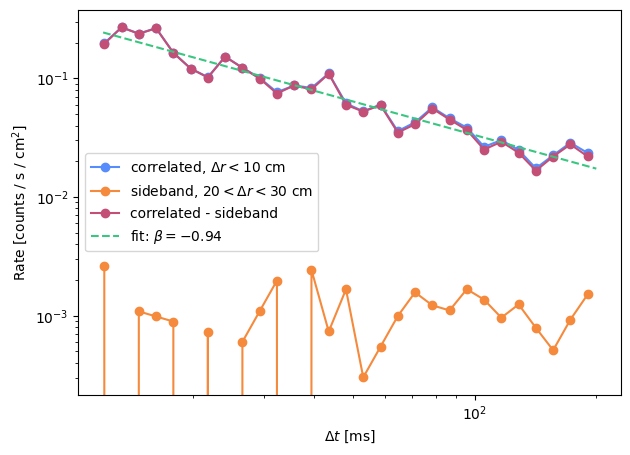

In [371]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 5))

plt.loglog(
    rate_df["dt_center_ms"],
    rate_df["rate_corr"],
    "o-",
    label=r"correlated, $\Delta r<10$ cm"
)

plt.loglog(
    rate_df["dt_center_ms"],
    rate_df["rate_uncorr"],
    "o-",
    label=r"sideband, $20<\Delta r<30$ cm"
)

plt.loglog(
    rate_df["dt_center_ms"],
    rate_df["rate_excess"],
    "o-",
    label="correlated - sideband"
)

dt_fit = np.logspace(np.log10(12), np.log10(200), 200)
plt.loglog(
    dt_fit,
    alpha * dt_fit**beta,
    "--",
    label=fr"fit: $\beta={beta:.2f}$"
)

plt.xlabel(r"$\Delta t$ [ms]")
plt.ylabel(r"Rate [counts / s / cm$^2$]")
plt.legend()
plt.show()

In [373]:
sum_prog_ne = np.nansum(clean_prog["n_electron_rec"])
rate_corr_per_e = N_corr / (dt_width_s * A_corr * sum_prog_ne)
rate_uncorr_per_e = N_uncorr / (dt_width_s * A_side * sum_prog_ne)
rate_excess_per_e = rate_corr_per_e - rate_uncorr_per_e

In [385]:
pairs_sub_dict = {}
for label, subtype_list in {
    "22": [22],
    "25": [25],
    "261_262": [261, 262],
    "29": [29],
}.items():
    prog_sub = clean_prog[np.isin(clean_prog["subtype"], subtype_list)]

    pairs_sub = progenitor_de_pairs(
        prog_sub,
        DEs,
        dt_min_ms=11.5,
        dt_max_ms=200.0,
        x_field="x",
        y_field="y",
    )

    print(label, "N progenitors:", len(prog_sub), "N pairs:", len(pairs_sub))

    pairs_sub_dict[label] = pairs_sub

22 N progenitors: 251 N pairs: 2149
25 N progenitors: 71 N pairs: 374
261_262 N progenitors: 82 N pairs: 583
29 N progenitors: 1 N pairs: 9


In [384]:
print(pairs_sub_dict.keys())

dict_keys(['29'])


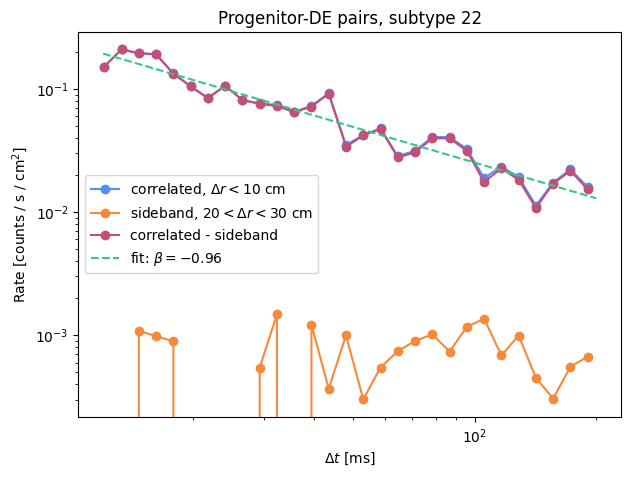

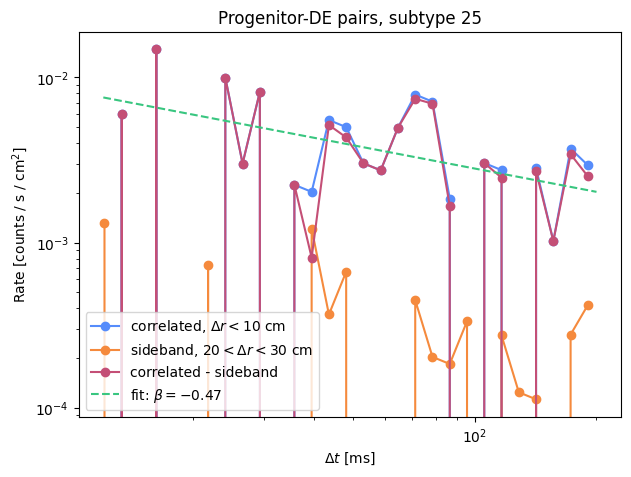

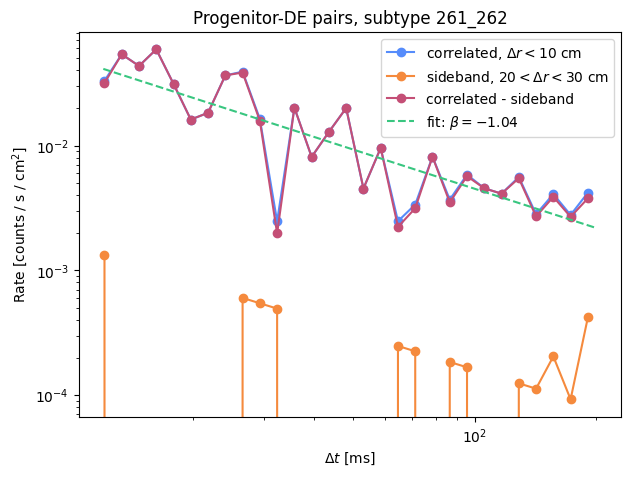

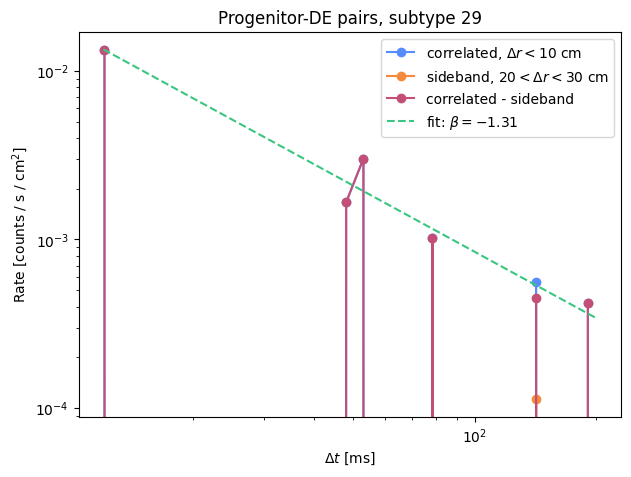

In [388]:
for label, subtype_list in {
    "22": [22],
    "25": [25],
    "261_262": [261, 262],
    "29": [29],
}.items():

    pairs_sub = pairs_sub_dict[label]
    corr = pairs_sub[pairs_sub["dr_cm"] < 10.0]

    uncorr = pairs_sub[
        (pairs_sub["dr_cm"] > 20.0)
        & (pairs_sub["dr_cm"] < 30.0)
    ]

    A_corr = np.pi * 10.0**2
    A_side = np.pi * (30.0**2 - 20.0**2)

    area_scale = A_corr / A_side

    expected_uncorr_in_corr = area_scale * len(uncorr)
    excess_corr = len(corr) - expected_uncorr_in_corr

    dt_edges = np.logspace(np.log10(11.5), np.log10(200.0), 30)

    N_corr, _ = np.histogram(corr["dt_ms"], bins=dt_edges)
    N_uncorr, _ = np.histogram(uncorr["dt_ms"], bins=dt_edges)

    dt_centers = np.sqrt(dt_edges[:-1] * dt_edges[1:])
    dt_width_s = np.diff(dt_edges) / 1000.0

    N_prog = len(clean_prog)

    rate_corr = N_corr / (N_prog * dt_width_s * A_corr)
    rate_uncorr = N_uncorr / (N_prog * dt_width_s * A_side)
    rate_excess = rate_corr - rate_uncorr

    rate_df = pd.DataFrame({
        "dt_center_ms": dt_centers,
        "N_corr": N_corr,
        "N_uncorr": N_uncorr,
        "N_excess_area_scaled": N_corr - area_scale * N_uncorr,
        "rate_corr": rate_corr,
        "rate_uncorr": rate_uncorr,
        "rate_excess": rate_excess,
    })

    fit_mask = (
        (rate_df["dt_center_ms"] >= 11.5)
        & (rate_df["dt_center_ms"] <= 200.0)
        & (rate_df["rate_excess"] > 0)
        & np.isfinite(rate_df["rate_excess"])
    )

    x = np.log(rate_df.loc[fit_mask, "dt_center_ms"])
    y = np.log(rate_df.loc[fit_mask, "rate_excess"])

    beta, log_alpha = np.polyfit(x, y, 1)
    alpha = np.exp(log_alpha)

    plt.figure(figsize=(7, 5))

    plt.loglog(
        rate_df["dt_center_ms"],
        rate_df["rate_corr"],
        "o-",
        label=r"correlated, $\Delta r<10$ cm"
    )

    plt.loglog(
        rate_df["dt_center_ms"],
        rate_df["rate_uncorr"],
        "o-",
        label=r"sideband, $20<\Delta r<30$ cm"
    )

    plt.loglog(
        rate_df["dt_center_ms"],
        rate_df["rate_excess"],
        "o-",
        label="correlated - sideband"
    )

    dt_fit = np.logspace(np.log10(12), np.log10(200), 200)
    plt.loglog(
        dt_fit,
        alpha * dt_fit**beta,
        "--",
        label=fr"fit: $\beta={beta:.2f}$"
    )

    plt.xlabel(r"$\Delta t$ [ms]")
    plt.ylabel(r"Rate [counts / s / cm$^2$]")
    plt.legend()
    plt.title(f"Progenitor-DE pairs, subtype {label}")
    plt.show()

In [389]:
summary_rows = []

for label in ["22", "25", "261_262", "29"]:
    pairs_sub = pairs_sub_dict[label]
    corr = pairs_sub[pairs_sub["dr_cm"] < 10.0]
    uncorr = pairs_sub[(pairs_sub["dr_cm"] > 20.0) & (pairs_sub["dr_cm"] < 30.0)]

    A_corr = np.pi * 10.0**2
    A_side = np.pi * (30.0**2 - 20.0**2)
    area_scale = A_corr / A_side

    excess = len(corr) - area_scale * len(uncorr)

    summary_rows.append({
        "subtype_group": label,
        "N_prog": len(clean_prog[np.isin(clean_prog["subtype"], {
            "22": [22],
            "25": [25],
            "261_262": [261, 262],
            "29": [29],
        }[label])]),
        "N_corr": len(corr),
        "N_sideband": len(uncorr),
        "N_excess_area_scaled": excess,
        "corr_per_prog": len(corr) / max(1, len(clean_prog[np.isin(clean_prog["subtype"], {
            "22": [22],
            "25": [25],
            "261_262": [261, 262],
            "29": [29],
        }[label])])),
        "excess_per_prog": excess / max(1, len(clean_prog[np.isin(clean_prog["subtype"], {
            "22": [22],
            "25": [25],
            "261_262": [261, 262],
            "29": [29],
        }[label])])),
    })

subtype_pair_summary = pd.DataFrame(summary_rows)
display(subtype_pair_summary)

,subtype_group,N_prog,N_corr,N_sideband,N_excess_area_scaled,corr_per_prog,excess_per_prog
0,22,251,932,83,915.4,3.713147,3.647012
1,25,71,73,26,67.8,1.028169,0.954930
2,261_262,82,197,18,193.4,2.402439,2.358537
3,29,1,8,1,7.8,8.000000,7.800000


In [423]:
source_like = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
]

burst_source = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] > 5)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [20, 271, 272, 273])
]

strong_burst_source = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
        & (debug["all_DEs_before_prompt"]["range_50p_area"] / 1e6 > 0.01)
        & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
    )
]

weak_sources = burst_source[
    ~np.isin(burst_source["time"], strong_burst_source["time"])
]

run_duration = (runs_df.iloc[0]['end'].value - runs_df.iloc[0]['start'].value)/1e9

ps2_bursts = pS2s[~np.isin(pS2s["time"], clean_prog["time"])]

window_size = 92.766 #seconds
base_width = 0.5 #seconds
margin = 3 #seconds

usable_start = margin
usable_end = run_duration - margin
usable_duration = usable_end - usable_start

n_windows = int(np.ceil(usable_duration / window_size))

results_list = []
values_list = []
cov_list = []
total_rate_list = []
diff_rate_list = []


for i in range(n_windows):

    start_sec = usable_start + i * window_size
    end_sec = min(start_sec + window_size, usable_end)

    if end_sec <= start_sec:
        break

    print(f"\n  window: {start_sec} - {end_sec} seconds")
    results_ps2_only, values_ps2_only, cov_ps2_only, total_ps2_only, diff_ps2_only = mod2.time_fitting(runs_df.iloc[0], clean_prog, ps2_bursts, strong_burst_source,
                                                                                                       DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), history = 5.0, model = 'exp_additive_ps2')

    results_ps2_weak, values_ps2_weak, cov_ps2_weak, total_ps2_weak, diff_ps2_weak = mod2.time_fitting(runs_df.iloc[0], clean_prog, ps2_bursts, strong_burst_source,
                                                                                                       DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), history = 5.0, model = 'exp_additive_ps2_weak')

    results_ps2_burst, values_ps2_burst, cov_ps2_burst, total_ps2_burst, diff_ps2_burst = mod2.time_fitting(runs_df.iloc[0], clean_prog,
                                                                                                ps2_bursts, strong_burst_source,
                                                                                                DEs, S1s['time_since_start'],
                                                                                                seconds_range = (start_sec, end_sec),
                                                                                                history = 5.0,
                                                                                                model = 'exp_additive_ps2_burst')

    results_ps2_burst_weak, values_ps2_burst_weak, cov_ps2_burst_weak, total_ps2_burst_weak, diff_ps2_burst_weak = (mod2.time_fitting
    (runs_df.iloc[0], clean_prog,ps2_bursts,strong_burst_source,DEs,S1s['time_since_start'],seconds_range = (start_sec,end_sec),history =
    5.0, model ='exp_additive_ps2_burst_weak'))


    results_list.append([results_ps2_only, results_ps2_weak, results_ps2_burst, results_ps2_burst_weak])
    values_list.append([values_ps2_only, values_ps2_weak, values_ps2_burst, values_ps2_burst_weak])
    cov_list.append([cov_ps2_only, cov_ps2_weak, cov_ps2_burst, cov_ps2_burst_weak])
    total_rate_list.append([total_ps2_only, total_ps2_weak, total_ps2_burst, total_ps2_burst_weak])
    diff_rate_list.append([diff_ps2_only, diff_ps2_weak, diff_ps2_burst, diff_ps2_burst_weak])

    pS2s_region_new = clean_prog[(clean_prog['time_since_start'] >= start_sec*1e3) & (clean_prog['time_since_start'] <= end_sec*1e3)]
    DEs_region_new = DEs[(DEs['time_since_start'] >= start_sec*1e3) & (DEs['time_since_start'] <= end_sec*1e3)]
    S1_region = S1s[(S1s['time_since_start'] >= start_sec*1e3) & (S1s['time_since_start'] <= end_sec*1e3)]
    weak_sources_new = weak_sources[(weak_sources['time_since_start'] >= start_sec*1e3) & (weak_sources['time_since_start'] <= end_sec*1e3)]
    strong_burst_source_new = strong_burst_source[(strong_burst_source['time_since_start'] >= start_sec*1e3) & (strong_burst_source['time_since_start'] <= end_sec*1e3)]

    available_width = end_sec - start_sec
    n_zooms = int(np.ceil(available_width / base_width))

    # for j in range(n_zooms):
    #     start_zoom = j*base_width
    #     if start_zoom >= available_width:
    #         break
    #
    #     zoom_width = min(base_width, available_width - start_zoom)
    #     if zoom_width < 0:
    #         break
    #
    #     plot_zoom = (start_zoom, zoom_width)
    #     print(f"  Zoom region: {start_zoom:.1f} - {start_zoom + zoom_width:.1f} seconds within window")
    #     print("running cdf_plot")
    #
    #     zoom_start_abs_ms = start_sec * 1e3 + start_zoom * 1e3
    #     zoom_stop_abs_ms = zoom_start_abs_ms + zoom_width * 1e3
    #
    #     se_zoom_times = DEs_region_new[
    #     (DEs_region_new["time_since_start"] >= zoom_start_abs_ms)
    #     & (DEs_region_new["time_since_start"] <= zoom_stop_abs_ms)]["time_since_start"]
    #
    #     resolution_ms = 10
    #     bins = np.arange(zoom_start_abs_ms, zoom_stop_abs_ms + resolution_ms, resolution_ms)
    #     hist, _ = np.histogram(se_zoom_times, bins=bins)
    #
    #     _, p_ps2_only, t_abs, _ = mod2.cdf_plot(
    #     pS2s_region_new,
    #     DEs_region_new,
    #     weak_sources_new,
    #     strong_burst_source_new,
    #     S1_region['time_since_start'],
    #     values_ps2_only,
    #     cov_ps2_only,
    #     model='exp_additive_ps2',
    #     label='exp+plaw with only PS2s',
    #     color='blue',
    #     seconds_range=(start_sec, end_sec),
    #     plot_zoom=plot_zoom,
    #     extra_models=[
    #     {
    #         "model": "exp_additive_ps2_weak",
    #         "values": values_ps2_weak,
    #         "cov": cov_ps2_weak,
    #         "label": "exp+plaw with PS2s and weak sources",
    #         "color": "orange",
    #         "linestyle": "-"
    #     },
    #     {
    #     "model": "exp_additive_ps2_burst",
    #     "values": values_ps2_burst,
    #     "cov": cov_ps2_burst,
    #     "label": "Exp+plaw with PS2s and burst sources",
    #     "color": "blue",
    #     "linestyle": "--"
    #     },
    #     {
    #     "model": "exp_additive_ps2_burst_weak",
    #     "values": values_ps2_burst_weak,
    #     "cov": cov_ps2_burst_weak,
    #     "label": "Exp+plaw with PS2s, weak and burst sources",
    #     "color": "purple",
    #     "linestyle": ":"
    #     }],
    #     show_model_errors= False
    #     )


  window: 3.0 - 89.766 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: exp_additive_ps2
Running without DAQ vetos; cannot guarantee a clean fit.

Running the exp_additive_ps2 cost function now
minimization takes 35.7561 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.91e+04                   │              Nfcn = 265              │
│ EDM = 7.69e-06 (Goal: 0.0002)    │           time = 36.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Be

In [ ]:
fit_start_ms = 3.0 * 1000
fit_stop_ms = 89.766 * 1000

DE_times_all = np.asarray(DEs["time_since_start"], dtype=float)

# First apply the fit window
DE_times_fit = DE_times_all[
    (DE_times_all >= fit_start_ms)
    & (DE_times_all < fit_stop_ms)
]

# Then apply the same live/dead mask as in time_fitting
tmin = 11.5  # or values["tmin"]

s1_times = np.asarray(S1s["time_since_start"], dtype=float)

dead_intervals = mod2.build_dead_intervals(
    fit_start_ms,
    fit_stop_ms,
    clean_prog["time_since_start"],
    s1_times,
    tmin
)

live_intervals = mod2.build_live_intervals(
    fit_start_ms,
    fit_stop_ms,
    dead_intervals
)

live_mask = mod2.make_live_mask(DE_times_fit, live_intervals)
DE_times_used = DE_times_fit[live_mask]

print(len(DE_times_used))

In [416]:
pS2s_unclean = pS2s[np.isin(pS2s, clean_prog)]
print(len(pS2s))
print(len(clean_prog))
print(len(pS2s_unclean))

805
405
0


In [417]:
mask_clean = np.isin(pS2s["time"], clean_prog["time"])

pS2s_clean_recovered = pS2s[mask_clean]
pS2s_unclean = pS2s[~mask_clean]

print("all pS2s:", len(pS2s))
print("clean_prog:", len(clean_prog))
print("overlap by time:", len(pS2s_clean_recovered))
print("unclean:", len(pS2s_unclean))

all pS2s: 805
clean_prog: 405
overlap by time: 405
unclean: 400


In [425]:
source_like = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
]

burst_source = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["area"] > 500)
        | (debug["all_DEs_before_prompt"]["n_electron_rec"] > 5)
    )
    & np.isin(debug["all_DEs_before_prompt"]["subtype"], [20, 271, 272, 273])
]

strong_burst_source = debug["all_DEs_before_prompt"][
    (
        (debug["all_DEs_before_prompt"]["n_electron_rec"] >= 10)
        & (debug["all_DEs_before_prompt"]["range_50p_area"] / 1e6 > 0.01)
        & np.isin(debug["all_DEs_before_prompt"]["subtype"], [271, 272])
    )
]

weak_sources = burst_source[
    ~np.isin(burst_source["time"], strong_burst_source["time"])
]

run_duration = (runs_df.iloc[0]['end'].value - runs_df.iloc[0]['start'].value)/1e9

ps2_bursts = pS2s[~np.isin(pS2s["time"], clean_prog["time"])]

window_size = 92.766 #seconds
base_width = 0.5 #seconds
margin = 3 #seconds

usable_start = margin
usable_end = run_duration - margin
usable_duration = usable_end - usable_start

n_windows = int(np.ceil(usable_duration / window_size))

results_list = []
values_list = []
cov_list = []
total_rate_list = []
diff_rate_list = []


for i in range(n_windows):

    start_sec = usable_start + i * window_size
    end_sec = min(start_sec + window_size, usable_end)

    if end_sec <= start_sec:
        break

    print(f"\n  window: {start_sec} - {end_sec} seconds")
    results_ps2_only, values_ps2_only, cov_ps2_only, total_ps2_only, diff_ps2_only = mod2.time_fitting(runs_df.iloc[0], clean_prog, ps2_bursts, strong_burst_source,
                                                                                                       DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), history = 5.0, model = 'plaw_exp_ps2')

    results_ps2_weak, values_ps2_weak, cov_ps2_weak, total_ps2_weak, diff_ps2_weak = mod2.time_fitting(runs_df.iloc[0], clean_prog, ps2_bursts, strong_burst_source,
                                                                                                       DEs, S1s['time_since_start'], seconds_range = (start_sec, end_sec), history = 5.0, model = 'plaw_exp_ps2_weak')

    results_ps2_burst, values_ps2_burst, cov_ps2_burst, total_ps2_burst, diff_ps2_burst = mod2.time_fitting(runs_df.iloc[0], clean_prog,
                                                                                                ps2_bursts, strong_burst_source,
                                                                                                DEs, S1s['time_since_start'],
                                                                                                seconds_range = (start_sec, end_sec),
                                                                                                history = 5.0,
                                                                                                model = 'plaw_exp_ps2_burst')

    results_ps2_burst_weak, values_ps2_burst_weak, cov_ps2_burst_weak, total_ps2_burst_weak, diff_ps2_burst_weak = (mod2.time_fitting
    (runs_df.iloc[0], clean_prog,ps2_bursts,strong_burst_source,DEs,S1s['time_since_start'],seconds_range = (start_sec,end_sec),history =
    5.0, model ='plaw_exp_ps2_burst_weak'))


    results_list.append([results_ps2_only, results_ps2_weak, results_ps2_burst, results_ps2_burst_weak])
    values_list.append([values_ps2_only, values_ps2_weak, values_ps2_burst, values_ps2_burst_weak])
    cov_list.append([cov_ps2_only, cov_ps2_weak, cov_ps2_burst, cov_ps2_burst_weak])
    total_rate_list.append([total_ps2_only, total_ps2_weak, total_ps2_burst, total_ps2_burst_weak])
    diff_rate_list.append([diff_ps2_only, diff_ps2_weak, diff_ps2_burst, diff_ps2_burst_weak])

    pS2s_region_new = clean_prog[(clean_prog['time_since_start'] >= start_sec*1e3) & (clean_prog['time_since_start'] <= end_sec*1e3)]
    DEs_region_new = DEs[(DEs['time_since_start'] >= start_sec*1e3) & (DEs['time_since_start'] <= end_sec*1e3)]
    S1_region = S1s[(S1s['time_since_start'] >= start_sec*1e3) & (S1s['time_since_start'] <= end_sec*1e3)]
    weak_sources_new = weak_sources[(weak_sources['time_since_start'] >= start_sec*1e3) & (weak_sources['time_since_start'] <= end_sec*1e3)]
    strong_burst_source_new = strong_burst_source[(strong_burst_source['time_since_start'] >= start_sec*1e3) & (strong_burst_source['time_since_start'] <= end_sec*1e3)]

    available_width = end_sec - start_sec
    n_zooms = int(np.ceil(available_width / base_width))


  window: 3.0 - 89.766 seconds

------------------------------------------------------------------------------------------------------------------------

Running model: plaw_exp_ps2
Running without DAQ vetos; cannot guarantee a clean fit.

Running the plaw_exp_ps2 cost function now
minimization takes 779.3647 s
Minimisation Status: 
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.908e+04                  │              Nfcn = 526              │
│ EDM = 3.25e-05 (Goal: 0.0002)    │           time = 627.2 sec           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below cal

SystemError: CPUDispatcher(<function _plaw_exp_ps2_pdf_basic at 0x7be17d083b00>) returned a result with an exception set